# Cuaderno 03. Preparación de Características y Modelado Predictivo de Cancelación

# 7. Ingeniería de características

## 7.1 ¿Qué es Feature Engineering?

El *feature engineering* consiste en transformar la información existente en variables que representen mejor el fenómeno que se desea modelar.

No significa inventar datos. Significa cambiar la forma en que se representa la información para que sea más útil para el modelo y más fácil de interpretar desde el punto de vista del negocio.

## Ejemplo con `BeginDate`

Supongamos que tenemos la siguiente información:

```text
BeginDate = 2018-06-01
```

Esta columna contiene una fecha válida, pero la fecha exacta de ingreso no siempre es la representación más útil para el modelo.

La pregunta empresarial real no es:

> **¿En qué fecha ingresó el cliente?**

La pregunta más relevante es:

> **¿Cuánto tiempo lleva siendo cliente de Interconnect?**

Por esta razón, podemos transformar `BeginDate` en una variable de antigüedad:

```text
Tenure = 20 meses
```

## Utilidad de la transformación

La variable `Tenure` puede ayudar al modelo a identificar patrones como:

- Clientes nuevos con mayor riesgo de cancelación.
- Clientes antiguos con mayor estabilidad.
- Diferencias de comportamiento según el tiempo de permanencia.
- Relación entre la antigüedad y los cargos totales acumulados.

Este cambio de representación puede facilitar que el modelo capture mejor la relación entre la antigüedad del cliente y el riesgo de `Churn`.

## Idea principal

```text
Información original → Variable más representativa del fenómeno
```

En este caso:

```text
BeginDate → Tenure
```

El objetivo del *feature engineering* es construir variables que reflejen mejor la lógica del negocio, utilizando únicamente información disponible antes del momento en que se realiza la predicción.
"""

## 7.2 Las features que sí tienen justificación en nuestro EDA

Trabajar inicialmente con estas: 

1. tenure
2. HasInternet
3. HasPhone
4. InternetAddOnCount
5. StreamingCount
6. HasTechProtection
7. AutomaticPayment

## 7.3 Feature 1 — tenure

Esta probablemente sea la *feature* más importante que se construira manualmente.

## ¿Por qué es importante?

Durante el análisis exploratorio de datos observamos un patrón interesante en los clientes que cancelaron:

- Presentaban cargos mensuales (`MonthlyCharges`) más altos.
- Al mismo tiempo, tenían cargos totales (`TotalCharges`) más bajos.

Esta combinación sugiere una hipótesis de negocio:

> **Algunos clientes que cancelan podrían estar pagando una cantidad elevada cada mes, pero llevar relativamente poco tiempo como clientes de Interconnect.**

En otras palabras, podrían tratarse de clientes nuevos con tarifas mensuales altas que abandonan el servicio antes de acumular una facturación total considerable.

## Limitación del análisis anterior

Hasta este momento, no podemos comprobar directamente cuánto tiempo llevaba cada cliente en la empresa.

Disponíamos de:

```text
MonthlyCharges
TotalCharges
```

Pero no de una variable explícita que representara la duración de la relación con Interconnect.

## Construcción de `Tenure`

Para estudiar esta hipótesis, construiremos la variable:

```text
Tenure
```

Esta característica representará la antigüedad del cliente, es decir, el tiempo transcurrido desde `BeginDate` hasta una fecha de corte definida.

La transformación será:

```text
BeginDate → Tenure
```

De esta forma, podremos analizar directamente si los clientes con:

- Poca antigüedad.
- Cargos mensuales elevados.
- Cargos totales relativamente bajos.

presentan una mayor tasa de cancelación.

## Hipótesis de negocio

> **Los clientes nuevos con cargos mensuales elevados podrían presentar un mayor riesgo de `Churn`, debido a que cancelan antes de consolidar una relación prolongada con la empresa.**

La variable `Tenure` permitirá evaluar esta hipótesis de forma más directa y mejorar la representación del fenómeno que se desea modelar.

## 7.4 Primera dificultad: ¿cómo calcular `Tenure`?

Para calcular la antigüedad del cliente, necesitamos definir una fecha de referencia.

## Fecha de referencia

Utilizaremos la siguiente fecha:

```text
2020-02-01
```

Esta fecha se selecciona porque el documento indica que los datos son válidos al 1 de febrero de 2020.

En Python, podemos definirla de la siguiente manera:

```python
reference_date = pd.Timestamp("2020-02-01")
```

## Cálculo inicial

Después, podríamos calcular la diferencia entre la fecha de referencia y `BeginDate`:

```python
data["tenure"] = (
    reference_date - data["BeginDate"]
)
```

Sin embargo, esta operación produciría una variable de tipo:

```text
Timedelta
```

Por ejemplo:

```text
730 days
```

Aunque esta representación es técnicamente válida, no es la más fácil de interpretar desde el punto de vista empresarial.

## Representación en meses

Para el negocio, será más comprensible expresar la antigüedad en meses:

```text
Tenure = cantidad de meses que el cliente lleva en Interconnect
```

Por ejemplo:

```text
730 días ≈ 24 meses
```

Trabajar con meses facilitará el análisis de la relación entre la antigüedad, los cargos mensuales y la probabilidad de cancelación.

## 7.5 Una cuestión crítica: clientes que ya cancelaron

Para calcular correctamente `Tenure`, es necesario considerar de forma distinta a los clientes activos y a los clientes que ya cancelaron.

## Problema con utilizar siempre la fecha de referencia

Supongamos que un cliente tiene:

```text
BeginDate = 2017-01-01
EndDate   = 2019-10-01
```

Si calculáramos su antigüedad utilizando siempre la fecha de referencia:

```python
2020-02-01 - BeginDate
```

obtendríamos una antigüedad que incluiría meses posteriores a la cancelación.

Esto sería incorrecto porque el cliente ya no pertenecía a Interconnect durante ese periodo.

## Cálculo correcto según el estado del cliente

Para los clientes activos, se utilizará la fecha de referencia:

```text
Tenure = reference_date - BeginDate
```

Para los clientes que cancelaron, se utilizará la fecha de cancelación:

```text
Tenure = EndDate - BeginDate
```

En forma conceptual:

```text
Cliente activo:
BeginDate ───────────────────── 2020-02-01

Cliente que canceló:
BeginDate ───────── EndDate
```

## Regla general

La fecha final del cálculo debe ser:

- `reference_date` para los clientes activos.
- `EndDate` para los clientes que cancelaron.

De esta manera, `Tenure` representará el tiempo real durante el cual el cliente mantuvo una relación con Interconnect.

## Importancia para evitar información incorrecta

Esta construcción utiliza `EndDate` únicamente para calcular una variable histórica descriptiva y no como característica predictora del modelo.

La variable `EndDate` seguirá marcada como una columna prohibida para el modelado, ya que revela directamente el resultado de cancelación.

El objetivo es evitar que `Tenure` incluya tiempo posterior a la cancelación y garantizar que la variable represente correctamente la duración de la relación del cliente con la empresa.

## 7.6 ¿Esto causa *leakage*?

Esta es una pregunta fundamental al construir la variable `Tenure`.

## Uso de `EndDate`

La columna `EndDate` contiene información relacionada con la respuesta del modelo, ya que indica cuándo terminó la relación del cliente con Interconnect.

Por este motivo:

```text
EndDate nunca debe entrar directamente al modelo.
```

Sin embargo, podemos utilizarla para reconstruir la duración histórica real del contrato en este conjunto de datos.

Para cada cliente:

- Si continúa activo, calculamos la duración hasta `reference_date`.
- Si ya canceló, calculamos la duración hasta `EndDate`.

De esta forma, `Tenure` representa correctamente el tiempo que el cliente permaneció en la empresa.

## Limitación en un escenario real

En un escenario de predicción prospectiva, no conoceríamos la fecha futura de cancelación de un cliente.

Por lo tanto, el cálculo de `Tenure` tendría que realizarse utilizando la fecha actual disponible en el momento de la predicción:

```text
Tenure = fecha_de_predicción - BeginDate
```

Nunca deberíamos utilizar una fecha futura de cancelación para generar predicciones.

## Diferencia entre el dataset y producción

En este dataset, `Tenure` puede utilizar `EndDate` para representar históricamente la duración real del contrato.

Pero en producción, la variable tendría que calcularse utilizando únicamente información disponible hasta la fecha de predicción.

| Contexto | Fecha final utilizada |
|---|---|
| Dataset histórico | `EndDate` para clientes cancelados |
| Predicción en producción | Fecha actual de predicción |

## Conclusión

Esta variable es válida como representación histórica del cliente para este dataset, siempre que:

- `EndDate` no se incluya directamente en el modelo.
- Se documente claramente cómo se construyó `Tenure`.
- Se explique que la implementación en producción utilizaría la fecha de predicción, no una futura fecha de cancelación.

Esta distinción es esencial para evitar una discrepancia entre el entrenamiento y el uso real del modelo.

In [218]:
# Importaciones de librerias

from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report


In [219]:
# Modifica tu Celda 3 en el Cuaderno 3:
data = pd.read_csv('../data/interconnect_clean.csv', parse_dates=['BeginDate', 'EndDateParsed'])
print(f"Dataset cargado correctamente. Dimensiones: {data.shape}")

Dataset cargado correctamente. Dimensiones: (7043, 22)


In [220]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customerID        7043 non-null   object        
 1   BeginDate         7043 non-null   datetime64[ns]
 2   EndDate           7043 non-null   object        
 3   Type              7043 non-null   object        
 4   PaperlessBilling  7043 non-null   object        
 5   PaymentMethod     7043 non-null   object        
 6   MonthlyCharges    7043 non-null   float64       
 7   TotalCharges      7043 non-null   float64       
 8   gender            7043 non-null   object        
 9   SeniorCitizen     7043 non-null   int64         
 10  Partner           7043 non-null   object        
 11  Dependents        7043 non-null   object        
 12  InternetService   7043 non-null   object        
 13  OnlineSecurity    7043 non-null   object        
 14  OnlineBackup      7043 n

## 7.7 Calcular tenure en meses

In [221]:
# Primero definimos una fecha final efectiva:

reference_date = pd.Timestamp("2020-02-01")

data["EffectiveEndDate"] = (
    data["EndDateParsed"]
    .fillna(reference_date)
)

In [222]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customerID        7043 non-null   object        
 1   BeginDate         7043 non-null   datetime64[ns]
 2   EndDate           7043 non-null   object        
 3   Type              7043 non-null   object        
 4   PaperlessBilling  7043 non-null   object        
 5   PaymentMethod     7043 non-null   object        
 6   MonthlyCharges    7043 non-null   float64       
 7   TotalCharges      7043 non-null   float64       
 8   gender            7043 non-null   object        
 9   SeniorCitizen     7043 non-null   int64         
 10  Partner           7043 non-null   object        
 11  Dependents        7043 non-null   object        
 12  InternetService   7043 non-null   object        
 13  OnlineSecurity    7043 non-null   object        
 14  OnlineBackup      7043 n

In [223]:
# Ahora calculamos meses

data["tenure"] = (
    (data["EffectiveEndDate"].dt.year - data["BeginDate"].dt.year) * 12
    +
    (data["EffectiveEndDate"].dt.month - data["BeginDate"].dt.month)
)

## 7.8 Validar tenure

In [224]:
data["tenure"].describe()

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

In [225]:
data["tenure"].min()

0

In [226]:
assert data["tenure"].min() >= 0

In [227]:
data.groupby("Churn")["tenure"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
0,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
1,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


En esta etapa verificaremos formalmente la hipótesis que surgió durante el análisis exploratorio de datos.

La distribución de `Tenure` según `Churn` es la siguiente:

| Churn | Count | Mean | Std | Min | 25% | 50% | 75% | Max |
|---|---:|---:|---:|---:|---:|---:|---:|---:|
| 0 | 5,174 | 37.57 | 24.11 | 0 | 15 | 38 | 61 | 72 |
| 1 | 1,869 | 17.98 | 19.53 | 1 | 2 | 10 | 29 | 72 |

## Observación de los resultados

Esta salida debe analizarse prestando especial atención a tres elementos:

- La media.
- La mediana.
- Los cuartiles.

Los clientes que no cancelaron (`Churn = 0`) presentan:

```text
Media:    37.57 meses
Mediana:  38 meses
```

En cambio, los clientes que cancelaron (`Churn = 1`) presentan:

```text
Media:    17.98 meses
Mediana:  10 meses
```

La diferencia es considerable: los clientes que cancelaron tienen, en promedio, aproximadamente 19.59 meses menos de antigüedad.

## Diferencia en los cuartiles

También se observa una diferencia clara en la distribución:

| Percentil | Clientes que no cancelaron | Clientes que cancelaron |
|---|---:|---:|
| 25% | 15 meses | 2 meses |
| 50% — mediana | 38 meses | 10 meses |
| 75% | 61 meses | 29 meses |

Los clientes que cancelaron presentan valores menores en todos los cuartiles principales.

Además:

- El 50% de los clientes que cancelaron tenía una antigüedad de 10 meses o menos.
- El 50% de los clientes que no cancelaron tenía una antigüedad de 38 meses o menos.
- El 75% de los clientes que cancelaron tenía una antigüedad de 29 meses o menos.
- En los clientes que no cancelaron, el tercer cuartil alcanzaba los 61 meses.

## Interpretación

Los resultados respaldan claramente la hipótesis planteada durante el EDA:

> **Los clientes que cancelan tienden a tener una antigüedad considerablemente menor que los clientes que permanecen en la empresa.**

La variable `Tenure` no solo añade información técnica al dataset, sino que también representa un patrón de negocio interpretable: el riesgo de cancelación parece concentrarse especialmente entre los clientes nuevos.

## De hipótesis a evidencia

El EDA permitió formular una hipótesis:

```text
Los clientes con cargos mensuales elevados y cargos totales bajos
podrían ser clientes relativamente nuevos.
```

Después de construir `Tenure`, podemos comprobar que los clientes con `Churn = 1` efectivamente presentan una antigüedad menor:

```text
Tenure medio, Churn = 0: 37.57 meses
Tenure medio, Churn = 1: 17.98 meses
```

Por tanto, `Tenure` convierte una observación inicial del EDA en evidencia cuantitativa y se perfila como una variable especialmente relevante para predecir `Churn`.

## 7.9 ¿Conservar `BeginDate` después?

No utilizaremos `BeginDate` directamente como predictor del modelo.

## ¿Por qué?

Las variables:

```text
BeginDate
Tenure
```

contienen información temporal muy relacionada.

`BeginDate` indica cuándo comenzó la relación con la empresa, mientras que `Tenure` expresa directamente cuánto tiempo lleva —o cuánto tiempo llevó— el cliente en Interconnect.

Desde el punto de vista del negocio, `Tenure` tiene una interpretación más clara:

```text
¿Cuántos meses permaneció el cliente en la empresa?
```

Por esta razón, `Tenure` resulta más conveniente para el modelado.

## Decisión provisional

Más adelante, durante la selección final de variables, podremos excluir:

```text
BeginDate
```

y conservar:

```text
Tenure
```

Esto ayudaría a evitar incluir dos variables que representan esencialmente la misma dimensión temporal.

## Importante

Todavía no eliminaremos `BeginDate` del DataFrame maestro.

El DataFrame maestro debe conservar las variables originales y las variables derivadas mientras continuamos con:

- La validación de datos.
- El análisis exploratorio.
- La creación de nuevas features.
- La comparación de variables.
- La preparación del conjunto final para el modelado.

La eliminación de `BeginDate` se realizará más adelante, en una etapa específica de selección de variables.

## Regla de trabajo

```text
DataFrame maestro:
conservar BeginDate y Tenure.

Dataset final para el modelo:
probablemente conservar Tenure y excluir BeginDate.
```

Esta estrategia mantiene la trazabilidad de las transformaciones y evita eliminar prematuramente información que todavía podría ser útil durante el análisis.

## 7.10 Feature 2 — HasInternet

Durante la integración descubrimos:

- 1526 clientes sin servicio de Internet.

Después los representamos como:

InternetService = "No internet service"

Esto nos permite crear una feature más sencilla:

In [228]:
data["HasInternet"] = (
    data["InternetService"] != "No internet service"
).astype(int)

Interpretación:

- 1 → tiene Internet
- 0 → no tiene Internet

## 7.11 ¿Por qué crear `HasInternet` si `InternetService` ya contiene esa información?

`InternetService` ya permite identificar si el cliente tiene internet, pero combina dos conceptos distintos en una sola variable:

1. Si el cliente tiene servicio de internet.
2. Qué tecnología de internet utiliza.

## Categorías de `InternetService`

La variable contiene las siguientes categorías:

```text
DSL
Fiber optic
No internet service
```

Por lo tanto, cada categoría comunica simultáneamente dos tipos de información:

| `InternetService` | ¿Tiene internet? | Tecnología |
|---|---|---|
| `DSL` | Sí | DSL |
| `Fiber optic` | Sí | Fibra óptica |
| `No internet service` | No | Ninguna |

## Separación conceptual

Al crear `HasInternet`, dividimos esta información en dos variables con significados más específicos:

```text
HasInternet
→ ¿El cliente tiene servicio de internet?

InternetService
→ ¿Qué tecnología de internet utiliza?
```

Así, `HasInternet` representa la existencia del servicio, mientras que `InternetService` representa la tecnología contratada.

## Ventaja para el modelado

Esta separación puede facilitar que algunos modelos aprendan relaciones diferentes:

- Una relación asociada simplemente con tener internet.
- Otra relación asociada con el tipo específico de tecnología.
- Diferencias entre clientes sin internet, con DSL y con fibra óptica.

Esta representación puede ser especialmente útil para modelos lineales, porque las variables explícitas pueden facilitar la interpretación de cada efecto individual.

Por ejemplo, el modelo podría aprender que:

```text
Tener internet aumenta o reduce el riesgo de churn
```

y, por separado, que:

```text
La tecnología Fiber optic tiene un comportamiento distinto de DSL
```

## Redundancia controlada

`HasInternet` contiene información parcialmente redundante respecto a `InternetService`, pero esto no implica necesariamente que deba eliminarse automáticamente.

La decisión dependerá de:

- El modelo utilizado.
- La codificación de las variables categóricas.
- El rendimiento obtenido en validación.
- La interpretabilidad deseada.
- La posible multicolinealidad en modelos lineales.

Por ello, ambas variables pueden conservarse inicialmente y evaluarse durante la selección de features.

## Idea principal

> `InternetService` indica qué tecnología utiliza el cliente, mientras que `HasInternet` indica si el cliente tiene internet. Aunque ambas variables están relacionadas, cada una expresa una pregunta de negocio diferente.

## 7.12 Validación de HasInternet

In [229]:
data["HasInternet"].value_counts()

HasInternet
1    5517
0    1526
Name: count, dtype: int64

In [230]:
pd.crosstab(
    data["HasInternet"],
    data["InternetService"]
)

InternetService,DSL,Fiber optic,No internet service
HasInternet,,,
0,0,0,1526
1,2421,3096,0


## 7.13 Feature 3 — HasPhone

Actualmente:

MultipleLines:
- Yes
- No
- No phone service

In [231]:
data["HasPhone"] = (
    data["MultipleLines"] != "No phone service"
).astype(int)

In [232]:
data["HasPhone"].value_counts()

HasPhone
1    6361
0     682
Name: count, dtype: int64

In [233]:
pd.crosstab(
    data["HasPhone"],
    data["MultipleLines"]
)

MultipleLines,No,No phone service,Yes
HasPhone,,,
0,0,682,0
1,3390,0,2971


## 7.14 ¿Por qué no crear HasMultipleLines?

Se puede.

Pero ya tenemos: MultipleLines

que distingue:

- Yes
- No
- No phone service

Crear demasiadas variables redundantes puede añadir ruido.

Por ahora:

HasPhone sí tiene una interpretación nueva y útil.

## 7.15 Feature 4 — InternetAddOnCount

EL EDA mostró diferencias interesantes en:

- OnlineSecurity
- OnlineBackup
- DeviceProtection
- TechSupport

En lugar de mirar solamente cada servicio individual, podemos preguntarnos:

**¿Cuántos servicios adicionales de protección/soporte tiene el cliente?**

In [234]:
# definimos los sevicios de proteccion 
internet_addons = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport"
]

In [235]:
data["InternetAddOnCount"] = (
    data[internet_addons]
    .eq("Yes")
    .sum(axis=1)
)

## 7.16 ¿Qué hace `.eq("Yes")`?

La expresión:

```python
data[internet_addons].eq("Yes")
```

comprueba, celda por celda, si cada variable de servicio adicional contiene exactamente el valor:

```text
"Yes"
```

Las columnas incluidas en `internet_addons` podrían ser, por ejemplo:

```text
OnlineSecurity
OnlineBackup
DeviceProtection
TechSupport
```

## Resultado de la comparación

Conceptualmente, la operación produce una tabla de valores booleanos:

| OnlineSecurity | OnlineBackup | DeviceProtection | TechSupport |
|---|---|---|---|
| True | False | True | False |

Cada valor significa:

- `True`: el cliente tiene contratado ese servicio.
- `False`: el cliente no tiene contratado ese servicio.

## Conteo por cliente

Después aplicamos:

```python
.sum(axis=1)
```

El argumento `axis=1` indica que la suma se realiza horizontalmente, es decir, por filas.

Por ejemplo:

```text
True + False + True + False
```

se convierte en:

```text
1 + 0 + 1 + 0 = 2
```

En Python y pandas:

```text
True  equivale a 1
False equivale a 0
```

Por tanto, el resultado para ese cliente será:

```text
InternetAddOnCount = 2
```

## Interpretación

La variable derivada:

```python
InternetAddOnCount
```

representa cuántos servicios adicionales de internet tiene contratados cada cliente.

Ejemplo:

| OnlineSecurity | OnlineBackup | DeviceProtection | TechSupport | InternetAddOnCount |
|---|---|---|---|---:|
| Yes | No | Yes | No | 2 |
| No | No | Yes | Yes | 2 |
| Yes | Yes | Yes | Yes | 4 |
| No | No | No | No | 0 |

Esta transformación convierte varias columnas binarias en una sola medida que resume la cantidad de servicios adicionales contratados por cada cliente.

## 7.17 ¿Por qué tiene sentido `InternetAddOnCount`?

La variable `InternetAddOnCount` puede representar la profundidad de la relación del cliente con los servicios de internet de Interconnect.

No todos los clientes utilizan el servicio de la misma manera:

- Un cliente puede tener únicamente internet.
- Otro puede tener internet, seguridad, backup, protección y soporte.

Aunque ambos tengan contratado el servicio de internet, el nivel de vinculación con la empresa puede ser diferente.

## Ejemplo conceptual

### Cliente A

```text
Internet
```

Este cliente utiliza el servicio principal, pero no tiene servicios adicionales contratados.

### Cliente B

```text
Internet
+ OnlineSecurity
+ OnlineBackup
+ DeviceProtection
+ TechSupport
```

Este cliente utiliza varios servicios complementarios y tiene una relación más amplia con el ecosistema de Interconnect.

La variable resume esta diferencia:

| Cliente | Servicios adicionales | `InternetAddOnCount` |
|---|---|---:|
| A | Ninguno | 0 |
| B | Seguridad, backup, protección y soporte | 4 |

## Posibles interpretaciones de negocio

Un mayor número de servicios contratados podría estar relacionado con:

- **Mayor vinculación:** el cliente utiliza más productos de la empresa.
- **Mayor costo de cambio:** cancelar podría ser menos conveniente cuando varios servicios dependen del mismo proveedor.
- **Mayor integración en el ecosistema:** el cliente concentra más necesidades en Interconnect.
- **Mayor uso del servicio:** la contratación de complementos puede reflejar una relación más activa.

Sin embargo, estas interpretaciones son hipótesis de negocio, no conclusiones definitivas.

## Papel del modelo

El objetivo de crear esta feature no es asumir que más servicios implican automáticamente menor churn.

El objetivo es proporcionar al modelo una representación compacta de la cantidad de servicios adicionales contratados y permitir que los datos determinen si esa información aporta valor predictivo.

Por ejemplo, el modelo podría descubrir que:

```text
Los clientes sin servicios adicionales presentan una tasa de churn distinta.
```

También podría encontrar que la relación no es lineal o que solo ciertos niveles de `InternetAddOnCount` son relevantes.

## Idea principal

> `InternetAddOnCount` resume la profundidad de la relación del cliente con los servicios de internet. Las posibles explicaciones —vinculación, costo de cambio o uso del ecosistema— son hipótesis que deberán validarse mediante el análisis y el rendimiento del modelo.

## 7.18 Validar InternetAddOnCount

In [236]:
data["InternetAddOnCount"].value_counts().sort_index()

InternetAddOnCount
0    2793
1    1467
2    1372
3     941
4     470
Name: count, dtype: int64

In [237]:
assert data["InternetAddOnCount"].between(0, 4).all()

In [238]:
data.groupby("InternetAddOnCount")["Churn"].agg(
    ["mean", "count"]
)

,mean,count
InternetAddOnCount,,
0,0.297530,2793
1,0.388548,1467
2,0.237609,1372
3,0.124336,941
4,0.053191,470


Ahora analizaremos la relación entre la cantidad de servicios adicionales de internet contratados y la tasa media de cancelación (`Churn`).

Los resultados son:

| `InternetAddOnCount` | Tasa media de `Churn` | Número de clientes |
|---:|---:|---:|
| 0 | 0.30 | 2,793 |
| 1 | 0.39 | 1,467 |
| 2 | 0.24 | 1,372 |
| 3 | 0.12 | 941 |
| 4 | 0.05 | 470 |

## Observación de la tendencia

La relación no es completamente lineal.

Los clientes con un servicio adicional presentan la tasa media de cancelación más alta:

```text
InternetAddOnCount = 1 → Churn medio de 0.39
```

A partir de dos servicios adicionales, la tasa de cancelación disminuye progresivamente:

```text
2 servicios → 0.24
3 servicios → 0.12
4 servicios → 0.05
```

## Interpretación

Los clientes que tienen tres o cuatro servicios adicionales presentan una tasa de cancelación considerablemente menor que quienes tienen pocos o ningún servicio complementario.

Esto es compatible con la hipótesis de que una relación más profunda con el ecosistema de servicios podría asociarse con:

- Mayor vinculación.
- Mayor dependencia funcional.
- Mayor costo de cambio.
- Uso más amplio de los servicios de Interconnect.

Sin embargo, los clientes con exactamente un servicio adicional muestran una tasa de churn superior a la de los clientes sin servicios adicionales:

```text
0 servicios → 0.30
1 servicio   → 0.39
```

Por tanto, no sería correcto afirmar simplemente que contratar más servicios siempre reduce el churn.

## Importancia del tamaño de los grupos

También debemos considerar cuántos clientes hay en cada grupo:

- El grupo con cuatro servicios tiene 470 clientes.
- El grupo con un servicio tiene 1,467 clientes.
- El grupo con cero servicios tiene 2,793 clientes.

Las tasas observadas son útiles para detectar patrones, pero deberán evaluarse junto con:

- La estabilidad estadística de cada grupo.
- Posibles variables de confusión.
- El rendimiento en validación.
- La importancia de la feature dentro del modelo final.

## Conclusión

Los datos sugieren una tendencia general: los clientes con tres o cuatro servicios adicionales presentan menor churn.

Pero la relación tiene una particularidad importante: el grupo con un solo servicio adicional muestra la tasa más alta.

Por tanto, `InternetAddOnCount` parece contener información potencialmente útil, aunque su efecto podría ser no lineal y deberá ser aprendido y validado por el modelo.

In [239]:
# Análisis adicional de `InternetAddOnCount`

data.loc[
    data["HasInternet"] == 1
].groupby("InternetAddOnCount")["Churn"].agg(
    ["mean", "count"]
)

,mean,count
InternetAddOnCount,,
0,0.566693,1267
1,0.388548,1467
2,0.237609,1372
3,0.124336,941
4,0.053191,470


## Análisis adicional de `InternetAddOnCount`

Para comprender mejor esta feature, podemos restringir el análisis a los clientes que sí tienen contratado el servicio de internet:

```python
data.loc[
    data["HasInternet"] == 1
].groupby("InternetAddOnCount")["Churn"].agg(
    ["mean", "count"]
)
```

## ¿Qué pregunta responde?

Este análisis responde una pregunta más limpia:

> **Entre los clientes que sí tienen internet, ¿cómo cambia el churn según el número de servicios adicionales contratados?**

Al fijar `HasInternet = 1`, evitamos mezclar en el mismo análisis:

- Clientes que no tienen internet.
- Clientes que sí tienen internet, pero distintos niveles de servicios adicionales.

## Resultados

| `InternetAddOnCount` | Tasa media de `Churn` | Número de clientes |
|---:|---:|---:|
| 0 | 0.57 | 1,267 |
| 1 | 0.39 | 1,467 |
| 2 | 0.24 | 1,372 |
| 3 | 0.12 | 941 |
| 4 | 0.05 | 470 |

## Observación principal

Entre los clientes que tienen internet, aparece una tendencia muy clara:

```text
A mayor número de add-ons, menor tasa de churn.
```

La tasa de cancelación disminuye de la siguiente manera:

```text
0 add-ons → 0.57
1 add-on  → 0.39
2 add-ons → 0.24
3 add-ons → 0.12
4 add-ons → 0.05
```

La diferencia entre los extremos es especialmente notable:

```text
0 add-ons → 57% de churn
4 add-ons → 5% de churn
```

## Interpretación

Este resultado respalda la hipótesis de que, dentro del grupo de clientes con internet, una mayor profundidad de relación con los servicios adicionales se asocia con una menor probabilidad de cancelación.

Una posible explicación es que estos clientes presenten:

- Mayor vinculación con Interconnect.
- Mayor integración de servicios.
- Mayor costo de cambio.
- Mayor dependencia del ecosistema.
- Un uso más amplio de la oferta de internet.

Estas explicaciones son hipótesis de negocio. El análisis muestra una asociación, pero no demuestra causalidad.

## Comparación con el análisis global

En el análisis global, el grupo con cero add-ons tenía una tasa media de churn de `0.30`.

Al limitar el análisis a quienes tienen internet, ese valor aumenta a:

```text
0 add-ons y HasInternet = 1 → 0.57
```

Esto muestra que el contexto importa. Los clientes sin add-ons dentro del grupo que sí tiene internet presentan un comportamiento diferente al promedio combinado de todos los clientes.

## Conclusión

El análisis condicionado por `HasInternet` ofrece una interpretación más precisa de `InternetAddOnCount`.

La feature parece capturar una relación monotónica clara entre la cantidad de servicios adicionales y el churn entre los clientes con internet:

> **Los clientes con más add-ons presentan tasas de cancelación progresivamente menores.**

Aun así, `InternetAddOnCount` sigue siendo una feature candidata. Su valor definitivo deberá comprobarse mediante el rendimiento de los modelos en validación.

## 7.18.1. validación adicional para InternetAddOnCount

In [240]:
internet_addon_churn = (
    data.loc[data["HasInternet"] == 1]
    .groupby("InternetAddOnCount")["Churn"]
    .agg(["mean", "count"])
)

internet_addon_churn["churn_rate_pct"] = (
    internet_addon_churn["mean"] * 100
)

internet_addon_churn

,mean,count,churn_rate_pct
InternetAddOnCount,,,
0,0.566693,1267,56.669298
1,0.388548,1467,38.854806
2,0.237609,1372,23.760933
3,0.124336,941,12.433581
4,0.053191,470,5.319149


Para interpretar correctamente esta feature, analizaremos únicamente a los clientes que tienen contratado el servicio de internet.

```python
internet_addon_churn = (
    data.loc[data["HasInternet"] == 1]
    .groupby("InternetAddOnCount")["Churn"]
    .agg(["mean", "count"])
)

internet_addon_churn["churn_rate_pct"] = (
    internet_addon_churn["mean"] * 100
)

internet_addon_churn
```

## Resultados

| `InternetAddOnCount` | Mean | Count | `churn_rate_pct` |
|---:|---:|---:|---:|
| 0 | 0.57 | 1,267 | 56.67% |
| 1 | 0.39 | 1,467 | 38.85% |
| 2 | 0.24 | 1,372 | 23.76% |
| 3 | 0.12 | 941 | 12.43% |
| 4 | 0.05 | 470 | 5.32% |

## Interpretación

Entre los clientes que sí tienen internet, la tasa de cancelación disminuye de forma progresiva a medida que aumenta el número de servicios adicionales:

```text
0 add-ons → 56.67%
1 add-on  → 38.85%
2 add-ons → 23.76%
3 add-ons → 12.43%
4 add-ons → 5.32%
```

La diferencia entre los extremos es considerable:

```text
Clientes con 0 add-ons → 56.67% de churn
Clientes con 4 add-ons → 5.32% de churn
```

## ¿Por qué es necesario filtrar?

En el análisis global, el valor:

```text
InternetAddOnCount = 0
```

mezcla dos grupos diferentes:

- Clientes sin servicio de internet.
- Clientes con internet, pero sin servicios adicionales.

Esta mezcla dificulta la interpretación porque ambos grupos tienen `InternetAddOnCount = 0`, pero no representan la misma situación de negocio.

## El problema de la mezcla

Un cliente sin internet:

```text
HasInternet = 0
InternetAddOnCount = 0
```

no es equivalente a un cliente que tiene internet, pero ningún add-on:

```text
HasInternet = 1
InternetAddOnCount = 0
```

En el primer caso, el cliente no puede contratar servicios adicionales de internet.

En el segundo, el cliente tiene internet, pero no ha contratado servicios de protección, soporte o utilidad.

Al filtrar:

```python
data.loc[data["HasInternet"] == 1]
```

el análisis se limita al grupo donde `InternetAddOnCount` tiene una interpretación homogénea.

## Conclusión

El análisis condicionado por `HasInternet` elimina la confusión del valor cero y permite interpretar `InternetAddOnCount` correctamente:

> **Entre los clientes que tienen internet, una mayor cantidad de add-ons se asocia con una tasa de churn progresivamente menor.**

Este resultado fortalece la justificación de la feature, aunque su valor definitivo deberá comprobarse mediante experimentos de modelado y validación.

## 7.19 Feature 5 — StreamingCount

Tenemos:

- StreamingTV
- StreamingMovies

In [241]:
# representar cuántos servicios de streaming tiene

streaming_features = [
    "StreamingTV",
    "StreamingMovies"
]

data["StreamingCount"] = (
    data[streaming_features]
    .eq("Yes")
    .sum(axis=1)
)

In [242]:
data["StreamingCount"].value_counts().sort_index()

StreamingCount
0    3544
1    1559
2    1940
Name: count, dtype: int64

In [243]:
assert data["StreamingCount"].between(0, 2).all()

In [244]:
data.groupby("StreamingCount")["Churn"].agg(
    ["mean", "count"]
)

,mean,count
StreamingCount,,
0,0.227991,3544
1,0.314304,1559
2,0.294330,1940


## 7.20 ¿Por qué separar `StreamingCount` de `InternetAddOnCount`?

Aunque ambos grupos de variables están relacionados con los servicios contratados por el cliente, representan categorías de uso diferentes.

Por esta razón, no conviene mezclarlos prematuramente en un único contador.

## Dos grupos conceptualmente distintos

### Servicios de protección, soporte y utilidad

Estas variables representan servicios orientados a proteger, respaldar o facilitar el uso del servicio de internet:

```text
OnlineSecurity
OnlineBackup
DeviceProtection
TechSupport
```

Podemos resumirlas mediante:

```text
InternetAddOnCount
```

Esta variable indica cuántos servicios adicionales de protección, soporte o utilidad tiene contratados el cliente.

### Servicios de entretenimiento

Estas variables representan consumo de contenido y entretenimiento:

```text
StreamingTV
StreamingMovies
```

Podemos resumirlas mediante:

```text
StreamingCount
```

## Diferencia conceptual

| Grupo | Variables | Tipo de relación |
|---|---|---|
| Protección y utilidad | `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport` | Seguridad, soporte y funcionalidad |
| Entretenimiento | `StreamingTV`, `StreamingMovies` | Consumo de contenido |

Un cliente podría tener varios servicios de protección porque depende de internet para necesidades operativas o de seguridad.

Otro cliente podría contratar servicios de streaming principalmente por motivos de entretenimiento.

Aunque ambos tengan servicios adicionales, la naturaleza de la relación con la empresa puede ser diferente.

## ¿Por qué no crear un único contador?

Si sumáramos todos los servicios en una única variable, perderíamos información sobre la categoría de uso.

Por ejemplo, estos dos clientes tendrían el mismo total:

```text
Cliente A:
OnlineSecurity + TechSupport = 2 servicios

Cliente B:
StreamingTV + StreamingMovies = 2 servicios
```

Pero su comportamiento podría ser distinto porque utilizan los servicios con objetivos diferentes.

Al mantener las variables separadas, el modelo puede aprender relaciones independientes entre:

```text
Servicios de protección y utilidad
```

y:

```text
Servicios de entretenimiento
```

## Idea principal

> `InternetAddOnCount` y `StreamingCount` deben mantenerse separados porque representan dimensiones distintas de la relación del cliente con Interconnect: una asociada con protección y utilidad, y otra relacionada con entretenimiento.

Más adelante, el rendimiento del modelo determinará si ambas features aportan valor predictivo.

## 7.21 Feature 6 — HasTechProtection

El EDA mostró una señal particularmente fuerte en:

- OnlineSecurity
- TechSupport

Podemos probar una variable que represente si el cliente cuenta con al menos una de estas capas de protección/soporte.

In [245]:
data["HasTechProtection"] = (
    (data["OnlineSecurity"] == "Yes")
    |
    (data["TechSupport"] == "Yes")
).astype(int)

In [246]:
data["HasTechProtection"].value_counts().sort_index()

HasTechProtection
0    4079
1    2964
Name: count, dtype: int64

Interpretación:

- 1 → tiene OnlineSecurity o TechSupport
- 0 → no tiene ninguno

In [247]:
assert data["HasTechProtection"].between(0, 1).all()

In [248]:
data.groupby("HasTechProtection")["Churn"].agg(
    ["mean", "count"]
)

,mean,count
HasTechProtection,,
0,0.334151,4079
1,0.170715,2964


## 7.22 ¿Por qué no sustituimos las variables originales?

Muy importante.

Por ahora no vamos a borrar:

- OnlineSecurity
- TechSupport

Queremos comparar posteriormente si: variables originales

más: feature combinada, aportan valor.

Los algoritmos de árboles pueden aprender estas combinaciones automáticamente.

La Regresión Logística quizá se beneficie más de la feature explícita.

Esto nos permitirá observar diferencias entre familias de modelos.

## 7.23 Feature 7 — AutomaticPayment

El EDA encontró una diferencia fuerte en PaymentMethod.

Tenemos:

- Bank transfer (automatic)
- Credit card (automatic)
- Electronic check
- Mailed check

Podemos separar: pago automático vs pago manual.

In [249]:
automatic_payment_methods = [
    "Bank transfer (automatic)",
    "Credit card (automatic)"
]

data["AutomaticPayment"] = (
    data["PaymentMethod"]
    .isin(automatic_payment_methods)
    .astype(int)
)

In [250]:
# Validación

pd.crosstab(
    data["PaymentMethod"],
    data["AutomaticPayment"]
)

AutomaticPayment,0,1
PaymentMethod,,
Bank transfer (automatic),0,1544
Credit card (automatic),0,1522
Electronic check,2365,0
Mailed check,1612,0


## 7.24 ¿Por qué tiene sentido?

Porque el método exacto y la automatización responden preguntas diferentes.

* PaymentMethod
  → cómo paga

* AutomaticPayment
  → requiere o no acción recurrente del cliente

Podría existir una relación entre fricción de pago y churn.

Pero, nuevamente: no estamos diciendo que el pago automático cause permanencia. Estamos creando una representación que puede ayudar al modelo.

## 7.25 Revisar las nuevas features juntas

In [251]:
engineered_features = [
    "tenure",
    "HasInternet",
    "HasPhone",
    "InternetAddOnCount",
    "StreamingCount",
    "HasTechProtection",
    "AutomaticPayment"
]

data[engineered_features].head()

,tenure,HasInternet,HasPhone,InternetAddOnCount,StreamingCount,HasTechProtection,AutomaticPayment
0,1,1,0,1,0,0,0
1,34,1,1,2,0,1,0
2,2,1,1,2,0,1,0
3,45,1,0,3,0,1,1
4,2,1,1,0,0,0,0


## 7.26 Validación global

In [252]:
data[engineered_features].isna().sum()

tenure                0
HasInternet           0
HasPhone              0
InternetAddOnCount    0
StreamingCount        0
HasTechProtection     0
AutomaticPayment      0
dtype: int64

In [253]:
data[engineered_features].describe()

,tenure,HasInternet,HasPhone,InternetAddOnCount,StreamingCount,HasTechProtection,AutomaticPayment
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,32.371149,0.783331,0.903166,1.265654,0.772256,0.420843,0.435326
std,24.559481,0.412004,0.295752,1.286879,0.852573,0.493730,0.495835
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,9.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,29.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
75%,55.000000,1.000000,1.000000,2.000000,2.000000,1.000000,1.000000
max,72.000000,1.000000,1.000000,4.000000,2.000000,1.000000,1.000000


En esta etapa revisaremos conjuntamente las variables derivadas que hemos construido:

```text
Tenure
HasInternet
HasPhone
InternetAddOnCount
StreamingCount
HasTechProtection
AutomaticPayment
```

La tabla descriptiva es:

| Estadístico | `Tenure` | `HasInternet` | `HasPhone` | `InternetAddOnCount` | `StreamingCount` | `HasTechProtection` | `AutomaticPayment` |
|---|---:|---:|---:|---:|---:|---:|---:|
| Count | 7,043 | 7,043 | 7,043 | 7,043 | 7,043 | 7,043 | 7,043 |
| Mean | 32.37 | 0.78 | 0.90 | 1.27 | 0.77 | 0.42 | 0.44 |
| Std | 24.56 | 0.41 | 0.30 | 1.29 | 0.85 | 0.50 | 0.50 |
| Min | 0.00 | 0.00 | 0.00 | 0.00 | 0.00 | 0.00 | 0.00 |
| 25% | 9.00 | 1.00 | 1.00 | 0.00 | 0.00 | 0.00 | 0.00 |
| 50% | 29.00 | 1.00 | 1.00 | 1.00 | 0.00 | 0.00 | 0.00 |
| 75% | 55.00 | 1.00 | 1.00 | 2.00 | 2.00 | 1.00 | 1.00 |
| Max | 72.00 | 1.00 | 1.00 | 4.00 | 2.00 | 1.00 | 1.00 |

## Validación de los conteos

Todas las variables presentan exactamente:

```text
7,043 observaciones
```

Esto indica que las features se calcularon para todas las filas del dataset y que no aparecen valores faltantes en estas columnas derivadas.

## Validación de rangos

Los rangos observados son coherentes con la definición de cada feature:

| Feature | Rango esperado | Rango observado |
|---|---|---|
| `Tenure` | 0 a 72 meses | 0 a 72 |
| `HasInternet` | 0 o 1 | 0 a 1 |
| `HasPhone` | 0 o 1 | 0 a 1 |
| `InternetAddOnCount` | 0 a 4 | 0 a 4 |
| `StreamingCount` | 0 a 2 | 0 a 2 |
| `HasTechProtection` | 0 o 1 | 0 a 1 |
| `AutomaticPayment` | 0 o 1 | 0 a 1 |

No se observan:

- Valores negativos.
- Valores superiores a los máximos posibles.
- Rangos incompatibles con la lógica de construcción.
- Errores evidentes de codificación.

## Interpretación general

### `Tenure`

La antigüedad media es de:

```text
32.37 meses
```

La mediana es de 29 meses y el rango va de 0 a 72 meses.

### Variables binarias

Las medias de las variables binarias pueden interpretarse como proporciones:

```text
HasInternet = 0.78
```

Esto significa que aproximadamente el 78% de los clientes tiene internet.

```text
HasPhone = 0.90
```

Aproximadamente el 90% tiene servicio telefónico.

```text
HasTechProtection = 0.42
```

Aproximadamente el 42% tiene contratado al menos uno de los servicios de protección considerados.

```text
AutomaticPayment = 0.44
```

Aproximadamente el 44% utiliza un método de pago automático, según la definición aplicada en la feature.

### Variables de conteo

`InternetAddOnCount` tiene una media de 1.27 servicios y puede tomar valores de 0 a 4.

`StreamingCount` tiene una media de 0.77 servicios y puede tomar valores de 0 a 2.

## Conclusión

La validación global confirma que las features derivadas:

- Tienen el número esperado de observaciones.
- Respetan sus rangos lógicos.
- No contienen valores negativos.
- No presentan valores imposibles evidentes.
- Son coherentes con la forma en que fueron construidas.

Esta revisión funciona como un control de calidad antes de continuar con el análisis de relaciones entre las nuevas variables y `Churn`.

## 7.27 Comparar las features con churn

In [254]:
binary_engineered_features = [
    "HasInternet",
    "HasPhone",
    "HasTechProtection",
    "AutomaticPayment"
]

for column in binary_engineered_features:
    print(f"\n{column}")
    display(
        data.groupby(column)["Churn"]
        .agg(["mean", "count"])
    )


HasInternet


,mean,count
HasInternet,,
0,0.074050,1526
1,0.318289,5517



HasPhone


,mean,count
HasPhone,,
0,0.249267,682
1,0.267096,6361



HasTechProtection


,mean,count
HasTechProtection,,
0,0.334151,4079
1,0.170715,2964



AutomaticPayment


,mean,count
AutomaticPayment,,
0,0.346744,3977
1,0.159817,3066


In [255]:
# para tenure

data.groupby("Churn")["tenure"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
0,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
1,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


In [256]:
# para conteos:

data.groupby("InternetAddOnCount")["Churn"].agg(
    ["mean", "count"]
)

,mean,count
InternetAddOnCount,,
0,0.297530,2793
1,0.388548,1467
2,0.237609,1372
3,0.124336,941
4,0.053191,470


In [257]:
data.groupby("StreamingCount")["Churn"].agg(
    ["mean", "count"]
)

,mean,count
StreamingCount,,
0,0.227991,3544
1,0.314304,1559
2,0.294330,1940


## 7.28 Todavía no estamos seleccionando features

En esta etapa estamos construyendo y analizando variables nuevas, pero aún no estamos tomando decisiones definitivas sobre cuáles permanecerán en el modelo.

## Una diferencia pequeña no implica eliminar la feature

Si una variable muestra poca diferencia en la tasa de `Churn` entre grupos, no debemos eliminarla automáticamente.

Una feature puede parecer poco relevante en un análisis descriptivo y, aun así:

- Aportar información cuando se combina con otras variables.
- Ayudar a un modelo no lineal.
- Capturar interacciones.
- Mejorar la calibración de las probabilidades.
- Aumentar el rendimiento fuera de la muestra.

Por eso, el análisis univariado sirve para comprender las variables, pero no basta para decidir su eliminación.

## La verdadera prueba

La pregunta importante será:

> **¿La inclusión de esta feature mejora el rendimiento del modelo en validación?**

Para responderla, tendremos que comparar experimentos controlados:

```text
Modelo base
vs.
Modelo base + nuevas features
```

La comparación deberá realizarse utilizando el mismo esquema de validación y las mismas métricas.

## Diferencia entre ingeniería y selección

### Ingeniería de características

La ingeniería de características consiste en:

- Crear variables derivadas.
- Incorporar conocimiento del negocio.
- Transformar variables existentes.
- Proponer nuevas representaciones de los clientes.

El resultado de esta etapa es un conjunto de candidatos potencialmente útiles.

### Selección de características

La selección ocurre después, mediante experimentación:

- Entrenamos modelos con distintas combinaciones.
- Evaluamos su rendimiento en validación.
- Comparamos las métricas.
- Revisamos estabilidad e interpretabilidad.
- Conservamos las variables que aportan valor demostrado.

## Flujo correcto

```text
Crear features
        ↓
Validar su construcción
        ↓
Analizar su relación con Churn
        ↓
Entrenar modelos
        ↓
Comparar rendimiento en validación
        ↓
Seleccionar variables
```

## Idea principal

> La ingeniería de características genera candidatos; la selección de features ocurre mediante experimentación y evidencia de validación.

Por ahora, las nuevas variables deben conservarse para que puedan evaluarse de forma conjunta dentro de los modelos.

## 7.29 Algo que debemos excluir posteriormente

Después de crear tenure, tendremos columnas como:

- BeginDate
- EndDate
- EndDateParsed
- EffectiveEndDate

Estas no deben entrar al modelo.

Especialmente:

- EndDate
- EndDateParsed
- EffectiveEndDate

porque contienen directa o indirectamente información de cancelación.

In [258]:
# Actualizamos

leakage_columns = [
    "EndDate",
    "EndDateParsed",
    "EffectiveEndDate"
]

### Antigüedad del cliente (`tenure`)

Durante el EDA se observó que los clientes que cancelaron presentan mayores cargos mensuales pero menores cargos totales acumulados. Este patrón sugiere que la antigüedad podría ser una variable relevante para explicar el churn.

Se creó `tenure` como el número de meses entre la fecha de inicio del contrato y la fecha efectiva de finalización.

Para clientes cuyo contrato seguía activo se utilizó como fecha de referencia el 1 de febrero de 2020, correspondiente a la fecha de corte del dataset.

Para clientes cuyo contrato había terminado se utilizó la fecha registrada en `EndDate`.

Esta variable representa la duración histórica de la relación contractual y deberá calcularse utilizando únicamente información disponible al momento de predicción en un escenario productivo.

### Indicadores de contratación de servicios

Se crearon las variables `HasInternet` y `HasPhone` para separar explícitamente la existencia del servicio de sus características particulares.

Las variables originales mezclan información sobre el tipo o configuración del servicio con categorías que representan la ausencia completa del mismo. Los nuevos indicadores permiten representar directamente si el cliente posee cada uno de los dos servicios principales de Interconnect.

### Conteo de servicios adicionales

El EDA mostró diferencias en la tasa de churn asociadas con distintos servicios complementarios de Internet.

Para representar el nivel de contratación de servicios adicionales se creó `InternetAddOnCount`, que contabiliza la contratación de seguridad en línea, backup, protección del dispositivo y soporte técnico.

Los servicios de streaming se contabilizaron por separado mediante `StreamingCount`, ya que representan un tipo de uso diferente a los servicios de soporte y protección.

Estas variables buscan representar el nivel de vinculación del cliente con el ecosistema de servicios sin sustituir las características originales.

### Pago automático

Durante el EDA se observaron diferencias importantes de churn entre los métodos de pago.

A partir de `PaymentMethod` se creó `AutomaticPayment`, que distingue entre métodos con cobro automático y métodos que requieren una acción manual de pago.

La variable permite evaluar si esta característica general del proceso de pago aporta información adicional al método específico utilizado.

## 7.30 Observar antes de cerrar el punto 7.

**A. tenure por churn**

In [259]:
data.groupby("Churn")["tenure"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
0,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
1,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


**B. InternetAddOnCount**

In [260]:
data.groupby("InternetAddOnCount")["Churn"].agg(
    ["mean", "count"]
)

,mean,count
InternetAddOnCount,,
0,0.297530,2793
1,0.388548,1467
2,0.237609,1372
3,0.124336,941
4,0.053191,470


**C. AutomaticPayment**

In [261]:
data.groupby("AutomaticPayment")["Churn"].agg(
    ["mean", "count"]
)

,mean,count
AutomaticPayment,,
0,0.346744,3977
1,0.159817,3066


**D. Validación de todas las nuevas variables**

In [262]:
data[engineered_features].describe()

,tenure,HasInternet,HasPhone,InternetAddOnCount,StreamingCount,HasTechProtection,AutomaticPayment
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,32.371149,0.783331,0.903166,1.265654,0.772256,0.420843,0.435326
std,24.559481,0.412004,0.295752,1.286879,0.852573,0.493730,0.495835
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,9.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,29.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
75%,55.000000,1.000000,1.000000,2.000000,2.000000,1.000000,1.000000
max,72.000000,1.000000,1.000000,4.000000,2.000000,1.000000,1.000000


In [263]:
data[engineered_features].isna().sum()

tenure                0
HasInternet           0
HasPhone              0
InternetAddOnCount    0
StreamingCount        0
HasTechProtection     0
AutomaticPayment      0
dtype: int64

## Evaluación de las features creadas

El conjunto actual de variables diseñadas manualmente es:

```text
Tenure
HasInternet
HasPhone
InternetAddOnCount
StreamingCount
HasTechProtection
AutomaticPayment
```

Estas variables no tienen todas el mismo nivel de evidencia, pero cada una cuenta con una justificación conceptual o empírica.

## Revisión individual

| Feature | Justificación | Evidencia actual | Consideración |
|---|---|---|---|
| `Tenure` | Representa la antigüedad del cliente | Señal descriptiva muy fuerte | Debe documentarse el riesgo metodológico de utilizar `EndDate` para clientes que cancelaron |
| `HasInternet` | Separa clientes con y sin servicio de internet | Útil para interpretar correctamente otras variables | Permite evitar mezclar clientes sin internet con clientes que tienen internet, pero no add-ons |
| `HasPhone` | Representa de forma explícita la existencia del servicio telefónico | Justificación semántica limpia | Todavía no se conoce su poder predictivo real |
| `InternetAddOnCount` | Resume la cantidad de servicios de protección, soporte y utilidad | Señal muy fuerte al analizarla dentro de clientes con internet | Su interpretación debe condicionarse a `HasInternet = 1` |
| `StreamingCount` | Resume los servicios de entretenimiento contratados | Feature válida, aunque la señal parece menor | Puede aportar información complementaria |
| `HasTechProtection` | Indica si el cliente tiene protección técnica | Diferencia clara, aproximadamente 33% frente a 17% | Parece una candidata relevante |
| `AutomaticPayment` | Identifica el uso de pago automático | Diferencia clara, aproximadamente 35% frente a 16% | Parece una candidata relevante |

## Diferentes niveles de evidencia

Podemos clasificar las features según la evidencia disponible:

### Señales fuertes

```text
Tenure
InternetAddOnCount
HasTechProtection
AutomaticPayment
```

Estas variables presentan patrones descriptivos importantes en relación con `Churn`.

### Variables de separación conceptual

```text
HasInternet
HasPhone
```

Su valor principal, por ahora, es representar explícitamente conceptos de negocio que estaban implícitos en variables categóricas originales.

### Señal posiblemente menor

```text
StreamingCount
```

La feature está bien justificada desde el punto de vista conceptual, pero el EDA inicial sugiere que su relación con `Churn` podría ser menos marcada.

Esto no implica que deba eliminarse automáticamente.

## Importante: todavía no estamos seleccionando

La evaluación descriptiva no determina por sí sola qué variables permanecerán en el modelo.

Una feature puede:

- Mostrar una diferencia clara de churn, pero aportar información redundante.
- Parecer débil de forma aislada, pero mejorar un modelo al combinarse con otras variables.
- Ser útil para un modelo lineal, pero no para otro algoritmo.
- Mejorar una métrica y empeorar otra.
- Aportar valor en segmentación o interpretación, aunque su ganancia predictiva sea pequeña.

La decisión final debe basarse en experimentos controlados de validación.

## Flujo de evaluación

```text
Features originales
        +
Features diseñadas
        ↓
Entrenamiento de modelos
        ↓
Validación con las mismas métricas
        ↓
Comparación contra un modelo base
        ↓
Evaluación de estabilidad e interpretabilidad
        ↓
Selección final
```

### Conclusiones de la ingeniería de características

A partir de los patrones identificados durante el análisis exploratorio se construyeron siete nuevas variables orientadas a representar de forma más directa la antigüedad, la contratación de servicios y características relevantes de la relación comercial.

La duración histórica del contrato muestra una asociación importante con churn. Los clientes que cancelaron presentan una duración contractual considerablemente menor que los clientes que permanecen. Sin embargo, dado que para clientes cancelados esta variable utiliza la fecha efectiva de terminación, su inclusión en el modelo deberá evaluarse cuidadosamente debido al posible riesgo de fuga de información temporal.

Entre los clientes con servicio de Internet se observa una relación clara entre `InternetAddOnCount` y churn. La tasa de cancelación disminuye progresivamente desde aproximadamente 57 % entre quienes no poseen add-ons hasta aproximadamente 5 % entre quienes poseen los cuatro servicios considerados.

`HasTechProtection` también presenta una diferencia relevante: los clientes sin seguridad en línea ni soporte técnico presentan aproximadamente el doble de churn que aquellos que cuentan con al menos uno de estos servicios.

Asimismo, `AutomaticPayment` muestra una asociación importante con permanencia, con una tasa de churn considerablemente menor entre clientes que utilizan métodos automáticos de pago.

Las nuevas variables presentan rangos consistentes, no contienen valores ausentes y se conservarán como características candidatas. Su aportación predictiva real será evaluada posteriormente mediante validación de modelos, sin interpretar las asociaciones observadas como relaciones causales.

## Antes de pasar al punto 8 Separación de los datos, hay una decisión clave sobre tenure

Se tiene que separar:

**HistoricalTenure**

de: feature válida en producción

Porque el tenure actual utiliza EndDate para los clientes que ya cancelaron.

In [264]:
# Renombrar temporalmente esa variable

data = data.rename(
    columns={"tenure": "HistoricalTenure"}
)

In [265]:
print(data.columns.tolist())

['customerID', 'BeginDate', 'EndDate', 'Type', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines', 'EndDateParsed', 'Churn', 'EffectiveEndDate', 'HistoricalTenure', 'HasInternet', 'HasPhone', 'InternetAddOnCount', 'StreamingCount', 'HasTechProtection', 'AutomaticPayment']


In [266]:
# Actualizamos

engineered_features = [
    "HistoricalTenure",
    "HasInternet",
    "HasPhone",
    "InternetAddOnCount",
    "StreamingCount",
    "HasTechProtection",
    "AutomaticPayment"
]

# 8. Separación de datos

## 8.1 Objetivo

En esta etapa prepararemos los datos para entrenar y evaluar el modelo de machine learning.

Construiremos dos componentes:

```text
X → variables predictoras
y → variable objetivo: Churn
```

## Variables predictoras y objetivo

### `X`

`X` contendrá las variables que el modelo utilizará para realizar predicciones.

Entre ellas podrán incluirse:

- Variables originales seleccionadas.
- Features numéricas.
- Variables categóricas después de su codificación.
- Variables engineered, como `Tenure` o `InternetAddOnCount`.

### `y`

`y` contendrá exclusivamente la variable objetivo:

```text
Churn
```

Esta variable indica si el cliente canceló el servicio:

```text
0 → no canceló
1 → canceló
```

## Separación del dataset

Partiremos del dataset completo y lo dividiremos en dos subconjuntos:

```text
Dataset completo
        ↓
   ┌────────┐
   │ Train  │
   └────────┘
        +
   ┌────────┐
   │ Test   │
   └────────┘
```

### Conjunto de entrenamiento

El conjunto `Train` se utilizará para:

- Entrenar el modelo.
- Ajustar transformaciones.
- Aprender patrones en los datos.
- Comparar configuraciones durante la experimentación.

### Conjunto de prueba

El conjunto `Test` debe permanecer reservado hasta el final.

Se utilizará únicamente para:

- Medir el rendimiento final.
- Estimar cómo podría comportarse el modelo con datos no vistos.
- Realizar una evaluación imparcial después de seleccionar el enfoque definitivo.

## Regla fundamental

> El conjunto de prueba no debe utilizarse para tomar decisiones durante el desarrollo del modelo.

Esto significa que no debemos usar `Test` para:

- Seleccionar features.
- Elegir hiperparámetros.
- Comparar repetidamente modelos.
- Ajustar transformaciones.
- Decidir qué estrategia funciona mejor.

Si consultamos el test durante el desarrollo, deja de ser una evaluación verdaderamente independiente.

## Flujo de trabajo

```text
Dataset completo
        ↓
Separar X e y
        ↓
Dividir en Train y Test
        ↓
Experimentar utilizando Train
        ↓
Seleccionar el modelo final
        ↓
Evaluar una sola vez en Test
```

## Código conceptual

```python
X = data.drop(columns=["Churn"])
y = data["Churn"]
```

Después realizaremos la separación:

```python
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
```

El argumento `stratify=y` ayuda a conservar una proporción similar de clases en los conjuntos de entrenamiento y prueba.

La semilla `random_state=42` permite reproducir exactamente la misma división.

## Conclusión

El objetivo es construir correctamente `X` e `y`, separar los datos en `Train` y `Test`, y proteger el conjunto de prueba para que la evaluación final sea confiable.


## 8.2 Primero definimos qué columnas NO pueden entrar al modelo

Tenemos varias columnas que debemos excluir por razones distintas.

In [267]:
# Target

target_column = "Churn"

# Identificador
# customerID sirve para identificar clientes, pero no debe aprenderse como predictor.
identifier_columns = [
    "customerID"
]

# Leakage
# Estas columnas contienen información directa o derivada de la cancelación.
leakage_columns = [
    "EndDate",
    "EndDateParsed",
    "EffectiveEndDate"
]

# Fecha original
# Como ya construimos una representación temporal más interpretable, no queremos pasar la fecha cruda al modelo.

raw_date_columns = [
    "BeginDate"
]

## 8.3 ¿Qué hacemos con HistoricalTenure?

Aplicamos la decisión que tomamos en el punto 7.

Nuestro HistoricalTenure se construyó usando: **EndDate - BeginDate**, para quienes cancelaron.

Eso significa que utiliza información que no estaría disponible antes de la cancelación.

Por tanto, para nuestro modelo principal conservador, la excluiremos.

In [268]:
experimental_leakage_columns = [
    "HistoricalTenure"
]

In [269]:
excluded_columns = (
    [target_column]
    + identifier_columns
    + leakage_columns
    + raw_date_columns
    + experimental_leakage_columns
)

## 8.4 Crear X e y

In [270]:
X = data.drop(
    columns=excluded_columns
)

y = data[target_column].copy()

In [271]:
# comprobamos:

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7043, 23)
y shape: (7043,)


## 8.5 Validar que no se quedaron leakage accidentales

In [272]:
for column in leakage_columns:
    assert column not in X.columns

assert "HistoricalTenure" not in X.columns
assert "customerID" not in X.columns
assert "Churn" not in X.columns

print("No se detectaron columnas prohibidas en X.")

No se detectaron columnas prohibidas en X.


## 8.6 Revisar las columnas predictoras

In [273]:
X.columns.tolist()

['Type',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'MultipleLines',
 'HasInternet',
 'HasPhone',
 'InternetAddOnCount',
 'StreamingCount',
 'HasTechProtection',
 'AutomaticPayment']

## 8.7 ¿Por qué no hacer *encoding* antes del *split*?

Esta es una de las ideas metodológicas más importantes de esta etapa.

Sería tentador aplicar directamente:

```python
X_encoded = pd.get_dummies(X)
```

y después separar los datos en entrenamiento y prueba.

Sin embargo, ese orden puede provocar que el procesamiento utilice información del dataset completo antes de evaluar el modelo.

## Regla general

> Toda transformación que pueda aprender algo de los datos debe ajustarse utilizando únicamente el conjunto de entrenamiento.

Esto incluye, entre otras transformaciones:

- Codificación de variables categóricas.
- Escalado numérico.
- Imputación de valores faltantes.
- Selección basada en estadísticas.
- Reducción de dimensionalidad.
- Creación de categorías aprendidas a partir de los datos.

## Orden correcto

El flujo correcto es:

```text
Dataset completo
        ↓
Separar Train y Test
        ↓
Ajustar encoder y scaler usando Train
        ↓
Transformar Train
        ↓
Transformar Test utilizando lo aprendido en Train
```

Conceptualmente:

```text
TRAIN
  ↓
fit encoder/scaler
  ↓
transform train
  ↓
transform test usando lo aprendido en train
```

El conjunto de prueba nunca debe participar en el ajuste del preprocesamiento.

## Orden incorrecto

No debemos hacer:

```text
TODO EL DATASET
        ↓
fit preprocessing
        ↓
split
```

En ese caso, el preprocesamiento habría visto información del conjunto de prueba antes de la evaluación.

## ¿Qué problema puede causar?

Si el encoder o cualquier otra transformación se ajusta con todo el dataset, el modelo puede beneficiarse indirectamente de información que debería permanecer reservada.

Esto genera una estimación demasiado optimista del rendimiento y reduce la confiabilidad de la evaluación final.

Aunque `pd.get_dummies()` parezca una transformación sencilla, trabajar directamente con ella antes del split puede dificultar:

- Mantener exactamente las mismas columnas entre Train y Test.
- Gestionar categorías que aparecen solo en uno de los conjuntos.
- Integrar correctamente el procesamiento dentro del flujo de validación.
- Evitar transformaciones aplicadas fuera del modelo.

## Solución: `Pipeline` y `ColumnTransformer`

Más adelante utilizaremos:

```python
Pipeline
ColumnTransformer
```

Estas herramientas permiten encapsular el preprocesamiento y el modelo en un único flujo.

Un esquema conceptual sería:

```python
preprocessor.fit(X_train, y_train)

X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)
```

En la práctica, el preprocesador se integrará dentro de un pipeline:

```python
pipeline.fit(X_train, y_train)
predictions = pipeline.predict(X_test)
```

Así, las transformaciones se ajustan con los datos de entrenamiento y luego se aplican al conjunto de prueba sin volver a aprender sus parámetros.

## Flujo completo

```text
X, y
 ↓
Train/Test split
 ↓
Pipeline:
    - preprocesamiento
    - entrenamiento del modelo
 ↓
Validación utilizando Train
 ↓
Evaluación final utilizando Test
```

## Idea principal

> Primero separamos los datos. Después ajustamos el preprocesamiento exclusivamente con `Train` y usamos ese conocimiento para transformar tanto `Train` como `Test`.

Este orden evita leakage y mantiene la evaluación del modelo metodológicamente correcta.

## 8.8 ¿Qué proporción utilizar?

El dataset contiene:

```text
7,043 clientes
```

No es un conjunto de datos enorme, pero sí tiene un tamaño suficiente para reservar una parte razonable para la evaluación final.

## Proporción propuesta

Utilizaremos:

```text
80% para entrenamiento
20% para prueba
```

La división aproximada será:

```text
7,043 × 0.8 ≈ 5,634 clientes para Train
7,043 × 0.2 ≈ 1,409 clientes para Test
```

| Conjunto | Proporción | Tamaño aproximado |
|---|---:|---:|
| `Train` | 80% | 5,634 clientes |
| `Test` | 20% | 1,409 clientes |
| Total | 100% | 7,043 clientes |

## ¿Por qué reservar un 20%?

Un conjunto de prueba de aproximadamente 1,409 clientes permite:

- Evaluar el modelo con una cantidad razonable de observaciones.
- Mantener suficientes datos para el entrenamiento.
- Obtener una estimación más estable del rendimiento.
- Contar con una cantidad suficiente de clientes con `Churn = 1`.

Esto es especialmente importante porque la clase positiva —los clientes que cancelaron— es menor que la clase negativa.

## Usar `stratify`

La división debe conservar aproximadamente la misma proporción de `Churn` en ambos conjuntos:

```python
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
```

El argumento:

```python
stratify=y
```

evita que el conjunto de prueba reciba una proporción accidentalmente muy baja o muy alta de clientes que cancelaron.

## Proporción esperada de churn

En el dataset completo hay aproximadamente:

```text
27% de clientes con Churn = 1
```

Con una división estratificada, esperaríamos aproximadamente:

```text
Train: 5,634 clientes, incluidos unos 1,495 casos de churn
Test:  1,409 clientes, incluidos unos 374 casos de churn
```

Los valores exactos pueden variar ligeramente según la implementación de la división.

## Decisión

La proporción final será:

```text
80% Train
20% Test
```

El conjunto `Test` quedará reservado para la evaluación final y no se utilizará durante la selección de features, el ajuste de hiperparámetros ni la comparación de modelos.

## 8.9 División de datos: entrenamiento y prueba

In [274]:
# División de los datos en conjuntos de entrenamiento y prueba

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20, # 20 % test y 80 % traint
    random_state=12345, # Hace que la separación sea reproducible. 
    stratify=y # Conservar aproximadamente esa proporción en ambos conjuntos. (73.5 % no churn; 26.5 % churn)
)

# ¿Qué podría pasar sin stratify? La división es aleatoria. Podríamos acabar con:
# - Train → 24 % churn
# - Test  → 36 % churn
# No sería imposible. 
# Eso haría que entrenamiento y evaluación tengan distribuciones distintas por puro azar.

## 8.10 Comprobar tamaños

In [275]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5634, 23)
X_test: (1409, 23)
y_train: (5634,)
y_test: (1409,)


## 8.11 Validar proporción de churn

In [276]:
print(
    "Churn dataset completo:",
    y.mean()
)

print(
    "Churn train:",
    y_train.mean()
)

print(
    "Churn test:",
    y_test.mean()
)

Churn dataset completo: 0.2653698707936959
Churn train: 0.2653532126375577
Churn test: 0.2654364797728886


## 8.12 Una tabla más clara

In [277]:
split_distribution = pd.DataFrame({
    "dataset": [
        "Complete",
        "Train",
        "Test"
    ],
    "customers": [
        len(y),
        len(y_train),
        len(y_test)
    ],
    "churn_rate": [
        y.mean(),
        y_train.mean(),
        y_test.mean()
    ]
})

split_distribution["churn_rate_pct"] = (
    split_distribution["churn_rate"] * 100
)

split_distribution

,dataset,customers,churn_rate,churn_rate_pct
0,Complete,7043,0.265370,26.536987
1,Train,5634,0.265353,26.535321
2,Test,1409,0.265436,26.543648


In [278]:
X_train.columns.tolist()

['Type',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'MultipleLines',
 'HasInternet',
 'HasPhone',
 'InternetAddOnCount',
 'StreamingCount',
 'HasTechProtection',
 'AutomaticPayment']

## 8.13 Validar que no exista solapamiento

Aunque train_test_split ya lo garantiza por índices, podemos comprobarlo.

In [279]:
train_indices = set(X_train.index)
test_indices = set(X_test.index)

assert train_indices.isdisjoint(test_indices)

print("Train y test no comparten observaciones.")

Train y test no comparten observaciones.


## 8.14 ¿Debemos tener un conjunto de validación separado?

Existen dos estrategias habituales para organizar los datos:

## Opción A: Train, Validation y Test

```text
Dataset completo
        ↓
 ┌───────────┐
 │   Train   │
 └───────────┘
       +
 ┌───────────┐
 │ Validation│
 └───────────┘
       +
 ┌───────────┐
 │   Test    │
 └───────────┘
```

Por ejemplo:

```text
60% Train
20% Validation
20% Test
```

En este esquema:

- `Train` se utiliza para entrenar el modelo.
- `Validation` se utiliza para comparar modelos y ajustar decisiones.
- `Test` se reserva para la evaluación final.

## Opción B: Train, validación cruzada y Test

La segunda alternativa es separar únicamente:

```text
80% Train
20% Test
```

y utilizar validación cruzada dentro del conjunto de entrenamiento:

```text
Train
  ↓
Stratified K-Fold Cross Validation
  ↓
Selección y ajuste del modelo
  ↓
Evaluación final en Test
```

En una validación cruzada de tipo K-Fold, el conjunto de entrenamiento se divide en varios folds. En cada iteración, el modelo se entrena con algunos folds y se valida con el fold restante. Al final, se agregan las métricas obtenidas en las distintas iteraciones. [9]

## Decisión para este dataset

Para este proyecto utilizaremos la opción B:

```text
80% Train
20% Test
```

Dentro del 80% destinado a entrenamiento aplicaremos:

```text
Stratified K-Fold Cross Validation
```

`StratifiedKFold` mantiene aproximadamente la misma proporción de clases en cada fold, algo importante porque `Churn` no está distribuido de manera uniforme entre sus categorías. [8]

## ¿Por qué preferimos esta opción?

El dataset contiene:

```text
7,043 clientes
```

Si reserváramos simultáneamente un conjunto de validación independiente, reduciríamos notablemente la cantidad de datos disponibles para entrenar cada modelo:

```text
60% Train      ≈ 4,226 clientes
20% Validation ≈ 1,409 clientes
20% Test       ≈ 1,409 clientes
```

En cambio, con la opción elegida:

```text
80% Train ≈ 5,634 clientes
20% Test  ≈ 1,409 clientes
```

La validación cruzada permite utilizar diferentes partes del conjunto `Train` para entrenar y validar durante las distintas iteraciones, aprovechando mejor los datos disponibles.

## Esquema recomendado

```python
from sklearn.model_selection import train_test_split, StratifiedKFold

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
```

Después, el objeto `cv` se utilizará para evaluar los modelos exclusivamente dentro de `X_train` e `y_train`.

## Papel del conjunto de prueba

El conjunto `Test` debe permanecer reservado durante todo el proceso de desarrollo.

No debemos utilizarlo para:

- Seleccionar features.
- Ajustar hiperparámetros.
- Comparar repetidamente modelos.
- Elegir el número de folds.
- Decidir qué preprocesamiento funciona mejor.

Una vez seleccionado el enfoque final mediante validación cruzada, evaluaremos el modelo definitivo una sola vez en `Test`.

## Conclusión

Para este dataset, la estrategia más conveniente es:

```text
80% Train
20% Test
```

y dentro de `Train`:

```text
Stratified K-Fold Cross Validation
```

Esta organización conserva un conjunto de prueba independiente y permite aprovechar mejor los 7,043 clientes disponibles durante el desarrollo del modelo.

## 8.15 Nuestra arquitectura experimental

La arquitectura experimental del proyecto seguirá un flujo estándar:

```text
                         DATASET
                            │
                    train_test_split
                            │
              ┌─────────────┴─────────────┐
              │                           │
            TRAIN                         TEST
             80%                          20%
              │                           │
              │                        NO TOCAR
              │
      Stratified Cross-Validation
              │
      Modelos y ajuste de parámetros
              │
          Selección final
              │
              └──────────────────────────┐
                                         ↓
                                  EVALUACIÓN FINAL
                                      EN TEST
```

## Primera división

Primero dividiremos el dataset completo en dos partes:

```text
80% → Train
20% → Test
```

El conjunto `Train` se utilizará durante todo el desarrollo.

El conjunto `Test` permanecerá reservado y no participará en las decisiones del proyecto.

```python
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
```

El argumento `stratify=y` ayuda a mantener una proporción similar de clientes con y sin churn en ambos conjuntos.

## Trabajo dentro de Train

Toda la experimentación se realizará utilizando únicamente `Train`.

Dentro de este conjunto aplicaremos validación cruzada estratificada:

```python
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
```

La validación cruzada permitirá comparar diferentes alternativas, por ejemplo:

- Modelos distintos.
- Conjuntos de features diferentes.
- Hiperparámetros.
- Estrategias de preprocesamiento.
- Métodos de balanceo, si fueran necesarios.

## Preprocesamiento correcto

El preprocesamiento también debe ajustarse dentro del flujo de validación.

Conceptualmente:

```text
Fold de entrenamiento
        ↓
fit del preprocesador
        ↓
transform del fold de entrenamiento
        +
transform del fold de validación
        ↓
Entrenamiento y evaluación del modelo
```

Por esta razón utilizaremos `Pipeline` y `ColumnTransformer`, evitando que la información de los folds de validación se utilice al ajustar el preprocesamiento.

## Selección del modelo final

Después de comparar las alternativas mediante validación cruzada, seleccionaremos:

- El conjunto de features.
- El algoritmo.
- Los hiperparámetros.
- El pipeline de preprocesamiento.

Luego entrenaremos el pipeline final utilizando todos los datos de `Train`.

```text
Train completo
      ↓
fit del pipeline final
      ↓
modelo definitivo
```

## Evaluación final

Solo después de completar la selección, utilizaremos el conjunto `Test`:

```python
final_model.fit(X_train, y_train)

y_test_pred = final_model.predict(X_test)
y_test_proba = final_model.predict_proba(X_test)[:, 1]
```

El rendimiento calculado sobre `Test` será nuestra estimación final sobre datos no utilizados durante el desarrollo.

## Regla fundamental

> `Test` se consulta una sola vez, después de finalizar la selección del modelo.

Si utilizáramos repetidamente el conjunto de prueba para tomar decisiones, terminaríamos adaptando indirectamente el proyecto a esos datos y la evaluación dejaría de ser completamente independiente.

## Conclusión

La arquitectura final será:

```text
Dataset completo
        ↓
80% Train / 20% Test
        ↓
Cross-validation dentro de Train
        ↓
Modelos y tuning
        ↓
Selección final
        ↓
Entrenamiento con Train completo
        ↓
Evaluación final en Test
```

Esta separación mantiene un flujo experimental claro, reduce el riesgo de leakage y conserva una evaluación final independiente.

## 8.16 ¿Qué significa “no tocar el test”?

Desde este punto NO utilizaremos X_test para:

- elegir features;
- elegir algoritmo;
- decidir hiperparámetros;
- seleccionar encoding;
- decidir escalado;
- elegir el mejor modelo.

Todo eso se hará con:

* X_train
* y_train

utilizando validación cruzada.

Solo al final utilizaremos:

* X_test
* y_test

una vez seleccionado el modelo.

## 8.16 Guardar customerID para trazabilidad

Aunque customerID no entre al modelo, queremos saber después qué cliente produjo cada predicción.

Antes del split podemos usar los índices originales para recuperar IDs.

In [280]:
customer_ids = data["customerID"]

In [281]:
customer_id_train = customer_ids.loc[X_train.index]
customer_id_test = customer_ids.loc[X_test.index]

In [282]:
# Validamos

len(customer_id_test) == len(X_test)

True

Esto será útil posteriormente para crear una tabla:

- customerID
- probability_churn
- prediction
- actual_churn

perfecta para API/dashboard/análisis de negocio.

## 8.17 Identificar columnas numéricas y categóricas

Todavía no las transformaremos.

Pero conviene identificarlas:

In [283]:
numeric_features = (
    X_train
    .select_dtypes(include=["int64", "float64"])
    .columns
    .tolist()
)

categorical_features = (
    X_train
    .select_dtypes(include=["object", "category"])
    .columns
    .tolist()
)

In [284]:
print("Variables numéricas:")
print(numeric_features)

print("\nVariables categóricas:")
print(categorical_features)

Variables numéricas:
['MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'HasInternet', 'HasPhone', 'InternetAddOnCount', 'StreamingCount', 'HasTechProtection', 'AutomaticPayment']

Variables categóricas:
['Type', 'PaperlessBilling', 'PaymentMethod', 'gender', 'Partner', 'Dependents', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines']


- **SeniorCitizen**
- **HasInternet**
- **AutomaticPayment**

son indicadores binarios.

## 8.18 Validaciones finales del split

In [285]:
assert len(X_train) + len(X_test) == len(X)

assert len(y_train) + len(y_test) == len(y)

assert X_train.index.equals(y_train.index)
assert X_test.index.equals(y_test.index)

assert set(X_train.index).isdisjoint(
    set(X_test.index)
)

print("Separación de datos validada correctamente.")

Separación de datos validada correctamente.


### Separación de los datos

El conjunto de datos se dividió en entrenamiento y prueba utilizando una proporción de 80/20.

Se utilizó una división estratificada respecto a `Churn` para conservar aproximadamente la misma proporción de clientes que cancelan en ambos subconjuntos.

El conjunto de prueba permanecerá aislado durante la selección de variables, construcción de pipelines, comparación de algoritmos y optimización de hiperparámetros. La selección del modelo se realizará utilizando validación cruzada sobre el conjunto de entrenamiento y el test será utilizado únicamente para la evaluación final.

Antes de la separación se excluyeron las variables que contienen información directa o indirecta de la cancelación (`EndDate`, `EndDateParsed` y `EffectiveEndDate`), así como el identificador `customerID`.

`HistoricalTenure` también fue excluida del conjunto principal debido a que para clientes que cancelaron fue construida utilizando la fecha efectiva de terminación, información que no estaría disponible en un escenario prospectivo de predicción.

Los identificadores de cliente se conservaron por separado para mantener la trazabilidad de las predicciones sin utilizarlos como características del modelo.

# 9. Construcción del pipeline

## 9.1 Objetivo

Queremos construir un flujo reproducible que transforme los datos y entrene el modelo de manera ordenada:

```text
Datos crudos de Train
        ↓
Preprocesamiento
        ↓
Modelo
```

Para ello utilizaremos:

- `ColumnTransformer`: aplica transformaciones distintas según el tipo de columna.
- `OneHotEncoder`: convierte variables categóricas en variables numéricas.
- `StandardScaler`: escala las variables numéricas.
- `Pipeline`: encapsula el preprocesamiento y el modelo en un único objeto.

El objetivo es que cada modelo reciba exactamente el mismo tratamiento de datos y que todas las transformaciones se ajusten únicamente con el conjunto de entrenamiento.

## 9.2 ¿Por qué no transformar manualmente?

Podríamos hacer:

```python
X_train_encoded = pd.get_dummies(X_train)
X_test_encoded = pd.get_dummies(X_test)
```

Pero este enfoque puede causar problemas:

- Una categoría podría aparecer en `Train`, pero no en `Test`, o al contrario.
- Las columnas resultantes podrían no coincidir entre ambos conjuntos.
- El escalado podría aplicarse de forma inconsistente.
- El flujo tendría demasiados pasos manuales y sería más difícil de reproducir.

Con pipeline hacemos:

- **fit(train)**

y después:

- **predict(test)**

con el mismo procesamiento.

## 9.3 Separar tipos de variables

Pandas distingue entre object y numéricas, pero para ML nos interesa una clasificación más conceptual.

Para nuestro modelo principal:

**Variables numéricas continuas**

In [286]:
continuous_features = [
    "MonthlyCharges",
    "TotalCharges"
]

**Variables binarias o discretas**

In [287]:
binary_discrete_features = [
    "SeniorCitizen",
    "HasInternet",
    "HasPhone",
    "InternetAddOnCount",
    "StreamingCount",
    "HasTechProtection",
    "AutomaticPayment"
]

**Variables categóricas**

In [288]:
categorical_features = [
    "Type",
    "PaperlessBilling",
    "PaymentMethod",
    "gender",
    "Partner",
    "Dependents",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "MultipleLines"
]

In [289]:
# Comprueba que entre todas cubran las 23 columnas de X_train.
total_features = (
    len(continuous_features)
    + len(binary_discrete_features)
    + len(categorical_features)
)

print(total_features)

23


## 9.4 Validar cobertura de columnas

In [290]:
selected_features = (
    continuous_features
    + binary_discrete_features
    + categorical_features
)

print("Columnas X_train:", len(X_train.columns))
print("Columnas clasificadas:", len(selected_features))

Columnas X_train: 23
Columnas clasificadas: 23


In [291]:
# validamos

assert set(selected_features) == set(X_train.columns)

print("Todas las variables fueron clasificadas correctamente.")

Todas las variables fueron clasificadas correctamente.


## 9.5 ¿Qué tratamiento necesita cada grupo?

Cada grupo de variables requiere un tratamiento diferente.

### Variables continuas

Ejemplos:

```text
MonthlyCharges
TotalCharges
```

Para modelos lineales conviene escalarlas utilizando:

```python
StandardScaler()
```

### Variables binarias y discretas

Ejemplos:

```text
HasInternet
HasPhone
HasTechProtection
AutomaticPayment
InternetAddOnCount
StreamingCount
```

Ya son numéricas y tienen rangos claros, como:

```text
0 / 1
0–4
0–2
```

Por ahora las dejaremos sin transformar:

```text
passthrough
```

### Variables categóricas

Ejemplos:

```text
Month-to-month
Fiber optic
Electronic check
Yes
No
```

No pueden introducirse directamente en muchos modelos. Las convertiremos en variables binarias mediante:

```python
OneHotEncoder()
```

## Resumen

| Grupo | Tratamiento |
|---|---|
| Continuas | `StandardScaler()` |
| Binarias/discretas | `passthrough` |
| Categóricas | `OneHotEncoder()` |

## 9.6 Crear transformador numérico

In [292]:
# Para variable continuas

continuous_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

## 9.7 ¿Qué hace `StandardScaler`?

`StandardScaler` transforma cada variable numérica utilizando la estandarización:

$$
z = \frac{x - \mu}{\sigma}
$$

donde:

* $x$ es el valor original.
* $\mu$ es la media calculada a partir del conjunto de entrenamiento.
* $\sigma$ es la desviación estándar calculada a partir del conjunto de entrenamiento.
* $z$ es el valor estandarizado resultante.

Por ejemplo, un valor como:

```text
MonthlyCharges = 80
```

deja de expresarse directamente en unidades monetarias y pasa a una escala estandarizada que indica qué tan alejado se encuentra respecto a la media del conjunto de entrenamiento.

Después de aplicar `StandardScaler`, las variables transformadas en el conjunto de entrenamiento tendrán aproximadamente:

```text
Media ≈ 0
Desviación estándar ≈ 1
```

El scaler se ajusta **únicamente con los datos de entrenamiento (`Train`)**. Posteriormente, los mismos parámetros aprendidos —media y desviación estándar— se utilizan para transformar tanto `Train` como `Test`.

Esto es importante porque evita utilizar información del conjunto de prueba durante el entrenamiento y reduce el riesgo de **data leakage**.

El escalado resulta especialmente útil para modelos como la Regresión Logística, ya que las variables pueden tener escalas muy diferentes. Por ejemplo:

```text
MonthlyCharges → decenas o centenas
TotalCharges   → miles
```

Al estandarizarlas, ambas variables quedan en escalas comparables, lo que facilita la optimización numérica del modelo y hace que la regularización se aplique de forma más equilibrada.


## 9.8 ¿Por qué es útil para Regresión Logística?

Las variables pueden estar en escalas muy diferentes:

```text
TotalCharges          → 0–8000
HasInternet           → 0–1
InternetAddOnCount    → 0–4
```

La Regresión Logística utiliza optimización numérica y regularización. Por eso, escalar las variables continuas puede:

- Mejorar la estabilidad numérica.
- Facilitar la convergencia del algoritmo.
- Hacer que la regularización sea más comparable entre variables.

Con `StandardScaler`, las variables continuas se llevan a una escala común sin modificar su información relativa.

## 9.9 ¿Y los árboles?

Los modelos basados en árboles, como:

```text
Random Forest
Gradient Boosting
```

generalmente no necesitan escalado, porque toman decisiones mediante divisiones de valores.

Esto no significa que el pipeline anterior esté mal. Podemos construir pipelines específicos para cada familia de modelos.

Para el primer baseline lineal, utilizar:

```python
StandardScaler()
```

sí tiene sentido.

## 9.10 Transformador categórico

In [293]:
categorical_transformer = Pipeline(
    steps=[
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

## 9.11 ¿Qué hace `OneHotEncoder`?

Supongamos que tenemos una variable categórica:

```text
Type
----------------
Month-to-month
One year
Two year
```

No debemos convertirla arbitrariamente en valores numéricos:

```text
Month-to-month = 0
One year       = 1
Two year       = 2
```

Esto introduciría una distancia y un orden numérico que no necesariamente existen:

```text
Two year > One year > Month-to-month
```

## Codificación One-Hot

`OneHotEncoder` crea una columna binaria para cada categoría:

```text
Type_Month-to-month
Type_One year
Type_Two year
```

Cada columna contiene únicamente:

```text
0 o 1
```

Por ejemplo:

| Type | Type_Month-to-month | Type_One year | Type_Two year |
|---|---:|---:|---:|
| Month-to-month | 1 | 0 | 0 |
| One year | 0 | 1 | 0 |
| Two year | 0 | 0 | 1 |

Así, cada categoría se representa sin imponer un orden numérico artificial.

## Configuración habitual

```python
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    handle_unknown="ignore"
)
```

El argumento `handle_unknown="ignore"` permite transformar categorías que aparezcan en `Test` pero que no hayan aparecido en `Train`, sin generar un error.

Dentro de un `Pipeline`, el encoder se ajusta con `Train` y después se aplica a los demás conjuntos utilizando las mismas columnas.

## 9.12 `handle_unknown="ignore"`

Este parámetro permite que el encoder gestione categorías que no aparecieron durante el entrenamiento.

Supongamos que `Train` contiene:

```text
DSL
Fiber optic
```

Más adelante, en `Test` o en producción, podría aparecer una categoría nueva.

Sin esta opción:

```python
OneHotEncoder()
```

el encoder podría generar un error al intentar transformar ese registro.

Con:

```python
OneHotEncoder(handle_unknown="ignore")
```

la categoría desconocida se procesa sin detener el pipeline. Sus columnas conocidas se codifican normalmente y la categoría nueva se representa sin activar ninguna columna previamente aprendida.

Esto hace que el flujo sea más robusto frente a categorías inesperadas en datos futuros.

## 9.13 Construir el ColumnTransformer

In [294]:
# unimos los tratamientos

preprocessor = ColumnTransformer(
    transformers=[
        (
            "continuous",
            continuous_transformer,
            continuous_features
        ),
        (
            "binary_discrete",
            "passthrough",
            binary_discrete_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ]
)

## 9.14 ¿Qué significa passthrough?

Significa:

conserva estas columnas sin transformarlas.

Por ejemplo:

HasInternet = 1

seguirá siendo:

1

No tiene sentido hacer OneHotEncoder de todas nuestras binarias manualmente.

## 9.15 ¿Por qué `Pipeline` previene *leakage* en Cross-Validation?

Supongamos que aplicamos una validación cruzada de 5 folds.

## Flujo incorrecto

Si ajustamos el preprocesamiento antes de la validación:

```text
Todo X_train
      ↓
fit scaler
      ↓
fit encoder
      ↓
Cross-Validation
```

el scaler y el encoder habrían utilizado información de todos los folds, incluidos los que después actuarán como validación.

Por tanto, cada fold de validación habría influido indirectamente en el preprocesamiento.

## Flujo correcto con `Pipeline`

Con `Pipeline`, el preprocesamiento se ajusta nuevamente dentro de cada iteración:

```text
Fold 1
  ├── Folds de entrenamiento
  │       ↓
  │   fit preprocessing
  │       ↓
  │   fit model
  │
  └── Fold de validación
          ↓
      transform + validate

Fold 2
  ├── Folds de entrenamiento
  │       ↓
  │   fit preprocessing
  │       ↓
  │   fit model
  │
  └── Fold de validación
          ↓
      transform + validate
```

En cada fold:

1. El preprocesamiento aprende únicamente de los datos de entrenamiento.
2. El modelo se ajusta con esos datos transformados.
3. El fold de validación solo se transforma y evalúa.

Así, cada validación simula mejor el comportamiento sobre datos realmente no vistos.

## Idea principal

> `Pipeline` mantiene unido el preprocesamiento y el modelo, garantizando que cada fold ajuste sus transformaciones sin utilizar información de su propio conjunto de validación.

## 9.16 Antes del modelo: comprobar el preprocessing

Podemos inspeccionarlo sin tocar test.

Usando solo una copia o el train:

In [295]:
X_train_transformed = preprocessor.fit_transform(X_train)

podemos hacerlo una sola vez para comprender el resultado, pero luego el modelado real debe utilizar el pipeline completo.

In [296]:
X_train_transformed.shape

(5634, 48)

## 9.17 ¿Por qué crece el número de columnas?

Por ejemplo: PaymentMethod tiene 4 categorías.

Una columna original puede convertirse en 4 columnas binarias.

Lo mismo con:

- InternetService
- Type
- MultipleLines
...

Por eso: 23 columnas originales pueden convertirse en bastantes más. Eso es normal.

## 9.18 Recuperar los nombres de features transformadas

Esto será útil más adelante para interpretabilidad.

Esto será especialmente útil para interpretar coeficientes de Logistic Regression.

In [297]:
feature_names = preprocessor.get_feature_names_out()

In [298]:
feature_names[:20]

array(['continuous__MonthlyCharges', 'continuous__TotalCharges',
       'binary_discrete__SeniorCitizen', 'binary_discrete__HasInternet',
       'binary_discrete__HasPhone', 'binary_discrete__InternetAddOnCount',
       'binary_discrete__StreamingCount',
       'binary_discrete__HasTechProtection',
       'binary_discrete__AutomaticPayment',
       'categorical__Type_Month-to-month', 'categorical__Type_One year',
       'categorical__Type_Two year', 'categorical__PaperlessBilling_No',
       'categorical__PaperlessBilling_Yes',
       'categorical__PaymentMethod_Bank transfer (automatic)',
       'categorical__PaymentMethod_Credit card (automatic)',
       'categorical__PaymentMethod_Electronic check',
       'categorical__PaymentMethod_Mailed check',
       'categorical__gender_Female', 'categorical__gender_Male'],
      dtype=object)

## 9.19 Evitar duplicar `.fit()`

En el notebook podemos transformar temporalmente los datos para inspeccionar el resultado del preprocesamiento:

```python
X_train_transformed = preprocessor.fit_transform(X_train)
```

Pero esta operación debe entenderse únicamente como una inspección académica.

No debemos sobrescribir el DataFrame original:

```python
# Evitar
X_train = preprocessor.fit_transform(X_train)
```

Al hacerlo, `X_train` dejaría de ser un DataFrame con sus columnas originales y pasaría a contener una matriz transformada.

## Flujo recomendado

Conservaremos ambos objetos separados:

```text
X_train
        → DataFrame original

X_train_transformed
        → resultado temporal para inspección
```

Después, para el entrenamiento real, utilizaremos un pipeline nuevo:

```python
pipeline.fit(X_train, y_train)
```

El pipeline se encargará de ajustar una sola vez el preprocesamiento y entrenar el modelo.

## Idea principal

> La transformación manual sirve para inspeccionar; el pipeline debe encargarse del entrenamiento real.

Así evitamos perder la estructura original del DataFrame y también evitamos duplicar innecesariamente el proceso de ajuste.

## 9.20 Validar que `Test` no fue utilizado

Hasta este punto, los conjuntos:

```text
X_test
y_test
```

deben permanecer intactos.

Nunca debemos ajustar el preprocesador utilizando el conjunto de prueba:

```python
# Incorrecto
preprocessor.fit(X_test)
```

Cuando llegue el momento de evaluar el modelo, el pipeline utilizará:

```text
transform(X_test)
```

aplicando los parámetros aprendidos exclusivamente con `Train`.

## 9.21 Prepararnos para Logistic Regression

In [299]:
# creamos
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

## 9.22 Construir el pipeline completo del baseline

In [300]:
logistic_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            logistic_model
        )
    ]
)

Ahora tenemos un único objeto que representa todo el flujo de transformación y modelado:

```text
Datos
  ↓
ColumnTransformer
  ├── Escalar variables continuas
  ├── Pasar variables binarias sin cambios
  └── Aplicar One-Hot Encoding a variables categóricas
  ↓
Regresión Logística
```

### Construcción del pipeline

Las variables predictoras se separaron según su naturaleza para aplicar un tratamiento adecuado antes del entrenamiento.

Las variables numéricas continuas `MonthlyCharges` y `TotalCharges` serán estandarizadas mediante `StandardScaler`, mientras que las variables categóricas serán codificadas mediante `OneHotEncoder`.

Los indicadores binarios y variables discretas creadas durante la ingeniería de características se conservarán en su representación numérica original.

El preprocesamiento se encapsuló dentro de un `ColumnTransformer` y posteriormente en un `Pipeline` junto con el modelo. Esta estrategia permite que las transformaciones se ajusten exclusivamente con los datos utilizados para entrenamiento en cada iteración y se apliquen de manera consistente a nuevos datos.

Además, esta arquitectura facilita la comparación posterior de diferentes algoritmos utilizando un flujo reproducible y reduce el riesgo de fuga de información durante la validación cruzada.

# 10. Modelos baseline

## 10.1 ¿Qué es un baseline?

Un *baseline* es un punto de referencia para evaluar el rendimiento de los modelos.

Si un modelo sofisticado obtiene:

```text
AUC-ROC = 0.81
```

este resultado no es suficiente por sí solo. Necesitamos compararlo con modelos más sencillos:

```text
DummyClassifier
→ ¿Qué ocurre sin aprender patrones reales?

LogisticRegression
→ ¿Qué rendimiento consigue un modelo lineal sencillo?
```

Después podremos determinar si modelos como:

```text
Random Forest
Gradient Boosting
CatBoost
```

aportan una mejora real frente a estas referencias.

## 10.2 Métricas que vamos a utilizar

La documentación de TripleTen establece:

- AUC-ROC como métrica principal
- Accuracy como métrica adicional.

Para esta etapa guardaremos:

- ROC-AUC
- Accuracy

pero la selección se guiará principalmente por ROC-AUC.

## 10.3 ¿Por qué no evaluar todavía en `X_test`?

El conjunto `Test` representa nuestra evaluación final, por lo que debe permanecer reservado durante la comparación de modelos.

Para comparar alternativas, utilizaremos únicamente:

```text
X_train
y_train
```

aplicando validación cruzada.

Conceptualmente:

```text
X_train
   ↓
Fold 1
Fold 2
Fold 3
Fold 4
Fold 5
   ↓
Promedio de métricas
```

Este procedimiento proporciona una estimación más robusta del rendimiento que una única partición interna.

## 10.4 Stratified K-Fold

In [301]:
# Importamos

from sklearn.model_selection import StratifiedKFold, cross_validate

In [302]:
# Definimos 

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

## ¿Qué significa `n_splits=5`?

El parámetro:

```python
n_splits=5
```

divide `X_train` aproximadamente en cinco partes, llamadas *folds*.

En cada ronda, una parte se utiliza para validar y las otras cuatro para entrenar:

```text
Ronda 1:
Fold 1 → validación
Folds 2, 3, 4 y 5 → entrenamiento

Ronda 2:
Fold 2 → validación
Folds 1, 3, 4 y 5 → entrenamiento

...

Ronda 5:
Fold 5 → validación
Folds 1, 2, 3 y 4 → entrenamiento
```

Al finalizar, se promedian las métricas obtenidas en las cinco rondas.

## Participación de cada observación

Cada observación de `X_train` participa:

```text
4 veces en entrenamiento
1 vez en validación
```

Así, todas las observaciones se utilizan para validar exactamente una vez, lo que proporciona una evaluación más estable del modelo.

## 10.5 ¿Por qué `StratifiedKFold`?

Utilizamos `StratifiedKFold` por la misma razón que usamos:

```python
stratify=y
```

en `train_test_split`.

Queremos que cada fold conserve aproximadamente la misma proporción de clases:

```text
26.5% → Churn = 1
73.5% → Churn = 0
```

Esto hace que las comparaciones entre modelos sean más estables y representativas.

## 10.6 Primer baseline: DummyClassifier

In [303]:
dummy_model = DummyClassifier(
    strategy="prior",
    random_state=42
)

## ¿Qué hace `strategy="prior"`?

`strategy="prior"` no aprende relaciones entre las features y `Churn`.

Simplemente utiliza la distribución observada de las clases:

```text
73.5% → no churn
26.5% → churn
```

Sus probabilidades reflejan esa distribución para todos los clientes.

Es deliberadamente un modelo “tonto” y, precisamente por eso, sirve como referencia.

## 10.7 ¿Dummy necesita preprocessing?

Técnicamente el DummyClassifier ignora X.

Pero para mantener una comparación consistente podríamos construirlo dentro del mismo pipeline:

In [304]:
dummy_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", dummy_model)
    ]
)

## 10.8 Definir las métricas de CV

In [305]:
scoring = {
    "roc_auc": "roc_auc",
    "accuracy": "accuracy"
}

## 10.9 Evaluar DummyClassifier

In [306]:
dummy_cv_results = cross_validate( # cross_validate(...) no toca X_test. Todo ocurre dentro de X_train.
    dummy_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

## 10.10 Ver resultados de cada fold

In [307]:
dummy_cv_results

{'fit_time': array([0.01152706, 0.00918102, 0.00908065, 0.00892901, 0.00792694]),
 'score_time': array([0.00799298, 0.00767684, 0.00767899, 0.00670624, 0.00705409]),
 'test_roc_auc': array([0.5, 0.5, 0.5, 0.5, 0.5]),
 'test_accuracy': array([0.73469388, 0.73469388, 0.73469388, 0.73469388, 0.73445826])}

**Nos interesan especialmente:**

In [308]:
dummy_cv_results["test_roc_auc"]

array([0.5, 0.5, 0.5, 0.5, 0.5])

In [309]:
dummy_cv_results["test_accuracy"]

array([0.73469388, 0.73469388, 0.73469388, 0.73469388, 0.73445826])

## 10.11 Resumir DummyClassifier

In [310]:
dummy_roc_auc_mean = (
    dummy_cv_results["test_roc_auc"].mean()
)

dummy_roc_auc_std = (
    dummy_cv_results["test_roc_auc"].std()
)

dummy_accuracy_mean = (
    dummy_cv_results["test_accuracy"].mean()
)

dummy_accuracy_std = (
    dummy_cv_results["test_accuracy"].std()
)

print(
    f"Dummy ROC-AUC: "
    f"{dummy_roc_auc_mean:.4f} "
    f"± {dummy_roc_auc_std:.4f}"
)

print(
    f"Dummy Accuracy: "
    f"{dummy_accuracy_mean:.4f} "
    f"± {dummy_accuracy_std:.4f}"
)

Dummy ROC-AUC: 0.5000 ± 0.0000
Dummy Accuracy: 0.7346 ± 0.0001


## Evaluación de los resultados de cada fold del modelo Dummy

Se analizaron los resultados obtenidos por el modelo Dummy mediante validación cruzada de 5 folds. El diccionario `dummy_cv_results` contiene los tiempos de entrenamiento (`fit_time`), los tiempos de evaluación (`score_time`) y las métricas calculadas sobre el conjunto de prueba de cada fold.

Los resultados de ROC AUC fueron:

```python
dummy_cv_results["test_roc_auc"]
```

```text
array([0.5, 0.5, 0.5, 0.5, 0.5])
```

Un ROC-AUC de 0.5 indica que el modelo no tiene capacidad discriminativa para ordenar clientes según riesgo de churn, equivalente al nivel de discriminación esperado de una clasificación sin información predictiva útil.
Los resultados de accuracy fueron:

```python
dummy_cv_results["test_accuracy"]
```

```text
array([0.73469388, 0.73469388, 0.73469388, 0.73469388, 0.73445826])
```

La accuracy promedio fue aproximadamente de 0.7346, es decir, 73.46 %. Sin embargo, este resultado debe interpretarse con precaución. El modelo Dummy puede obtener una accuracy relativamente alta al predecir siempre la clase mayoritaria, especialmente cuando existe un desequilibrio entre las clases.

Por lo tanto, la accuracy por sí sola no demuestra que el modelo tenga un buen desempeño. Para considerar que un modelo es útil, deberá superar al modelo Dummy, principalmente en ROC AUC y, según el objetivo del proyecto, también en otras métricas como precision, recall y F1-score.

En conclusión, el modelo Dummy establece las siguientes líneas base:

- ROC AUC promedio: 0.50.
- Accuracy promedio: aproximadamente 0.7346.
- Variación entre folds: muy baja.

Un modelo predictivo adecuado debería obtener un ROC AUC superior a 0.50 y mejorar el desempeño de referencia establecido por la accuracy del modelo Dummy.

## 10.13 Segundo baseline: Logistic Regression

Ya tenemos construido:

```text
logistic_pipeline
```

Este pipeline contiene:

```text
preprocessor
      +
LogisticRegression
```

No es necesario reconstruirlo. Ahora lo evaluaremos utilizando exactamente:

- El mismo objeto `cv`.
- Los mismos folds.
- Las mismas métricas.
- El mismo conjunto `X_train`, `y_train`.

```python
logistic_cv_results = cross_validate(
    logistic_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)
```

## Comparación justa

```text
DummyClassifier
      ↓
mismos folds y métricas

Logistic Regression
      ↓
mismos folds y métricas
```

De esta manera, cualquier diferencia en el rendimiento se atribuye al modelo y no a una división o configuración distinta.

In [311]:
logistic_cv_results = cross_validate(
    logistic_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

## 10.14 Resumir Logistic Regression

In [312]:
logistic_roc_auc_mean = (
    logistic_cv_results["test_roc_auc"].mean()
)

logistic_roc_auc_std = (
    logistic_cv_results["test_roc_auc"].std()
)

logistic_accuracy_mean = (
    logistic_cv_results["test_accuracy"].mean()
)

logistic_accuracy_std = (
    logistic_cv_results["test_accuracy"].std()
)

print(
    f"Logistic ROC-AUC: "
    f"{logistic_roc_auc_mean:.4f} "
    f"± {logistic_roc_auc_std:.4f}"
)

print(
    f"Logistic Accuracy: "
    f"{logistic_accuracy_mean:.4f} "
    f"± {logistic_accuracy_std:.4f}"
)

Logistic ROC-AUC: 0.8399 ± 0.0110
Logistic Accuracy: 0.8007 ± 0.0102


## 10.15 ¿Qué significa el símbolo `±`?

Supongamos que obtenemos:

```text
ROC-AUC = 0.84 ± 0.01
```

El valor:

```text
0.84
```

representa la media obtenida en los cinco folds.

El valor:

```text
0.01
```

representa la desviación estándar de los resultados entre los folds.

Esto permite evaluar la estabilidad del modelo.

## Ejemplo

```text
Modelo A → 0.85 ± 0.005
Modelo B → 0.86 ± 0.050
```

El Modelo B tiene una media ligeramente superior, pero sus resultados son mucho más variables.

Por tanto, no siempre elegiríamos automáticamente el Modelo B.

## Evaluación de la regresión logística mediante validación cruzada

En esta sección se calcularon el promedio y la desviación estándar de las métricas obtenidas por el modelo de regresión logística durante la validación cruzada.

El promedio de ROC-AUC se obtuvo mediante:

```python
logistic_roc_auc_mean = (
    logistic_cv_results["test_roc_auc"].mean()
)
```

Este valor resume el desempeño promedio del modelo en todos los folds. El resultado fue:

```text
Logistic ROC-AUC: 0.8399 ± 0.0110
```

El ROC-AUC promedio de 0.8399 indica que el modelo tiene una buena capacidad para distinguir entre las clases. Este resultado es considerablemente superior a 0.5, que representa un comportamiento similar al azar. Por lo tanto, la regresión logística aprendió relaciones útiles entre las variables predictoras y la variable objetivo.

La desviación estándar del ROC-AUC fue de 0.0110. Al ser un valor relativamente bajo, indica que el desempeño del modelo fue estable entre los diferentes folds de la validación cruzada. Esto sugiere que los resultados no dependen excesivamente de una partición específica de los datos.

Para la métrica accuracy se obtuvo:

```text
Logistic Accuracy: 0.8007 ± 0.0102
```

La accuracy promedio de 0.8007 significa que el modelo clasificó correctamente aproximadamente el 80.07 % de las observaciones. La desviación estándar de 0.0102 también es baja, lo que indica poca variación en la accuracy entre los folds. “Utilizando el umbral de clasificación predeterminado de 0.5”.

Al comparar estos resultados con el modelo Dummy, la regresión logística mostró una mejora importante. El modelo Dummy obtuvo un ROC-AUC de 0.5000 y una accuracy aproximada de 0.7346, mientras que la regresión logística obtuvo un ROC-AUC de 0.8399 y una accuracy de 0.8007.

Por lo tanto, la regresión logística supera claramente la línea base establecida por el modelo Dummy. La mejora en ROC-AUC demuestra que el modelo no solo predice la clase mayoritaria, sino que también tiene una capacidad considerable para distinguir entre clientes que abandonan el servicio y clientes que permanecen.

En conclusión, la regresión logística presenta un desempeño adecuado y estable para este problema. Sin embargo, la accuracy debe analizarse junto con otras métricas, como precision, recall, F1-score y la matriz de confusión, especialmente si existe un desequilibrio entre las clases.

## 10.16 Construir nuestra primera tabla de experimentos

Lo utilizaremos durante todo el modelado:

In [313]:
baseline_results = pd.DataFrame({
    "model": [
        "DummyClassifier",
        "LogisticRegression"
    ],
    "roc_auc_mean": [
        dummy_roc_auc_mean,
        logistic_roc_auc_mean
    ],
    "roc_auc_std": [
        dummy_roc_auc_std,
        logistic_roc_auc_std
    ],
    "accuracy_mean": [
        dummy_accuracy_mean,
        logistic_accuracy_mean
    ],
    "accuracy_std": [
        dummy_accuracy_std,
        logistic_accuracy_std
    ]
})

baseline_results

,model,roc_auc_mean,roc_auc_std,accuracy_mean,accuracy_std
0,DummyClassifier,0.500000,0.000000,0.734647,0.000094
1,LogisticRegression,0.839863,0.011029,0.800674,0.010221


## 10.17 Una mejora: ordenar por AUC

In [314]:
baseline_results = (
    baseline_results
    .sort_values(
        "roc_auc_mean",
        ascending=False
    )
    .reset_index(drop=True)
)

baseline_results

,model,roc_auc_mean,roc_auc_std,accuracy_mean,accuracy_std
0,LogisticRegression,0.839863,0.011029,0.800674,0.010221
1,DummyClassifier,0.500000,0.000000,0.734647,0.000094


Hasta ahora nuestro benchmark serio es:

**Logistic Regression**

- ROC-AUC ≈ 0.8399
- Accuracy ≈ 0.8007

Así que cualquier modelo más complejo debe demostrar que realmente aporta algo mejor y de forma estable.

# 11. Comparación de algoritmos

La idea será comparar varias familias:

- RandomForestClassifier
- GradientBoostingClassifier
- CatBoostClassifier
  
Y mantener exactamente:

- mismos X_train / y_train
- mismo StratifiedKFold
- mismas métricas
- mismo test congelado

## 11.1 Random Forest

In [315]:
random_forest_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

¿Por qué 300 árboles?

No es un hiperparámetro “óptimo”; es simplemente un valor razonable para obtener un baseline estable. El tuning vendrá en el punto 12.

In [316]:
# construimos pipeline:

random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", random_forest_model)
    ]
)

In [317]:
# Evaluamos

rf_cv_results = cross_validate(
    random_forest_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

In [318]:
# Resumen

rf_roc_auc_mean = rf_cv_results["test_roc_auc"].mean()
rf_roc_auc_std = rf_cv_results["test_roc_auc"].std()

rf_accuracy_mean = rf_cv_results["test_accuracy"].mean()
rf_accuracy_std = rf_cv_results["test_accuracy"].std()

print(
    f"Random Forest ROC-AUC: "
    f"{rf_roc_auc_mean:.4f} ± {rf_roc_auc_std:.4f}"
)

print(
    f"Random Forest Accuracy: "
    f"{rf_accuracy_mean:.4f} ± {rf_accuracy_std:.4f}"
)

Random Forest ROC-AUC: 0.8182 ± 0.0129
Random Forest Accuracy: 0.7820 ± 0.0075


## ¿Por qué probar Random Forest?

Random Forest puede capturar relaciones no lineales e interacciones entre variables automáticamente.

Por ejemplo, puede detectar un patrón combinado como:

```text
Type = Month-to-month
+
InternetService = Fiber optic
+
TechSupport = No
```

Una Regresión Logística no modelaría esta interacción de forma directa sin crear features adicionales.

## Desventajas

Random Forest puede:

- Sobreajustar con mayor facilidad.
- Ser menos interpretable que un modelo lineal.

Por eso no asumimos que será mejor. Su rendimiento debe comprobarse mediante validación cruzada.

### Random Forest

Se evaluó `RandomForestClassifier` como primer modelo no lineal.

Random Forest combina múltiples árboles de decisión construidos sobre diferentes muestras y subconjuntos de variables, lo que permite capturar relaciones no lineales e interacciones entre características.

El modelo se evaluó utilizando la misma validación cruzada estratificada de cinco folds y las mismas métricas empleadas para los modelos baseline, con el objetivo de mantener una comparación justa.

En esta etapa no se realizó optimización de hiperparámetros; el objetivo es determinar si la familia de modelos basada en árboles muestra una mejora respecto a la Regresión Logística.

## 11.2 Gradient Boosting

In [319]:
from sklearn.ensemble import GradientBoostingClassifier

In [320]:
# Modelo inicial

gradient_boosting_model = GradientBoostingClassifier(
    random_state=42
)

In [321]:
# Pipeline

gradient_boosting_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", gradient_boosting_model)
    ]
)

In [322]:
# Evaluación

gb_cv_results = cross_validate(
    gradient_boosting_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

In [323]:
# Resumen

gb_roc_auc_mean = gb_cv_results["test_roc_auc"].mean()
gb_roc_auc_std = gb_cv_results["test_roc_auc"].std()

gb_accuracy_mean = gb_cv_results["test_accuracy"].mean()
gb_accuracy_std = gb_cv_results["test_accuracy"].std()

print(
    f"Gradient Boosting ROC-AUC: "
    f"{gb_roc_auc_mean:.4f} ± {gb_roc_auc_std:.4f}"
)

print(
    f"Gradient Boosting Accuracy: "
    f"{gb_accuracy_mean:.4f} ± {gb_accuracy_std:.4f}"
)

Gradient Boosting ROC-AUC: 0.8477 ± 0.0097
Gradient Boosting Accuracy: 0.7984 ± 0.0103


## ¿Por qué Gradient Boosting?

A diferencia de Random Forest, los árboles de Gradient Boosting se construyen secuencialmente.

Cada nuevo árbol intenta corregir los errores cometidos por el modelo anterior:

```text
Modelo 1
   ↓
Errores
   ↓
Modelo 2 corrige parte de los errores
   ↓
Errores restantes
   ↓
Modelo 3
   ↓
...
```

Este proceso suele funcionar muy bien con datos tabulares.

### Gradient Boosting

Se evaluó `GradientBoostingClassifier` como modelo basado en árboles secuenciales.

A diferencia de Random Forest, Gradient Boosting construye árboles de forma progresiva, donde cada nuevo estimador intenta reducir los errores cometidos por el conjunto anterior.

Este enfoque puede capturar relaciones no lineales e interacciones complejas entre variables, por lo que resulta especialmente relevante para datos tabulares.

En esta etapa se utilizaron hiperparámetros iniciales sin realizar tuning, manteniendo la misma estrategia de validación cruzada y métricas utilizadas en los modelos anteriores.

## 11.3 CatBoost



Pero aquí hay una consideración:

nuestro pipeline actual ya hace:

**OneHotEncoder**

CatBoost puede manejar categorías directamente, así que usarlo después del One-Hot Encoding no aprovecha completamente una de sus mayores fortalezas.



**Alternativa A**

Usarlo dentro del mismo pipeline ya transformado.

Más sencillo para comparación.

In [324]:
from catboost import CatBoostClassifier

In [325]:
catboost_model = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.05,
    loss_function="Logloss",
    eval_metric="AUC",
    verbose=0,
    random_seed=42
)

In [326]:
# Pipeline

catboost_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", catboost_model)
    ]
)

In [327]:
# Evaluación

catboost_cv_results = cross_validate(
    catboost_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

In [328]:
# Resumen

cat_roc_auc_mean = (
    catboost_cv_results["test_roc_auc"].mean()
)

cat_roc_auc_std = (
    catboost_cv_results["test_roc_auc"].std()
)

cat_accuracy_mean = (
    catboost_cv_results["test_accuracy"].mean()
)

cat_accuracy_std = (
    catboost_cv_results["test_accuracy"].std()
)

In [329]:
print(
    f"CatBoost ROC-AUC: "
    f"{cat_roc_auc_mean:.4f} ± {cat_roc_auc_std:.4f}"
)

print(
    f"CatBoost Accuracy: "
    f"{cat_accuracy_mean:.4f} ± {cat_accuracy_std:.4f}"
)

CatBoost ROC-AUC: 0.8448 ± 0.0075
CatBoost Accuracy: 0.8007 ± 0.0084


### CatBoost

Se evaluó `CatBoostClassifier` como modelo de gradient boosting.

CatBoost está diseñado especialmente para problemas tabulares y puede capturar relaciones no lineales e interacciones complejas entre variables.

Aunque el algoritmo permite trabajar directamente con variables categóricas, en esta primera comparación se utilizó el mismo preprocesamiento empleado por los demás modelos para mantener una estructura experimental consistente.

La evaluación se realizó mediante validación cruzada estratificada de cinco folds, utilizando AUC-ROC como métrica principal y Accuracy como métrica adicional.

## 11.4 Añadirlos a nuestra tabla experimental

In [330]:
baseline_results

,model,roc_auc_mean,roc_auc_std,accuracy_mean,accuracy_std
0,LogisticRegression,0.839863,0.011029,0.800674,0.010221
1,DummyClassifier,0.500000,0.000000,0.734647,0.000094


In [331]:
# creamos una tabla más amplia

model_comparison = pd.DataFrame({
    "model": [
        "DummyClassifier",
        "LogisticRegression",
        "RandomForest",
        "GradientBoosting",
        "CatBoost"
    ],
    "roc_auc_mean": [
        dummy_roc_auc_mean,
        logistic_roc_auc_mean,
        rf_roc_auc_mean,
        gb_roc_auc_mean,
        cat_roc_auc_mean
    ],
    "roc_auc_std": [
        dummy_roc_auc_std,
        logistic_roc_auc_std,
        rf_roc_auc_std,
        gb_roc_auc_std,
        cat_roc_auc_std
    ],
    "accuracy_mean": [
        dummy_accuracy_mean,
        logistic_accuracy_mean,
        rf_accuracy_mean,
        gb_accuracy_mean,
        cat_accuracy_mean
    ],
    "accuracy_std": [
        dummy_accuracy_std,
        logistic_accuracy_std,
        rf_accuracy_std,
        gb_accuracy_std,
        cat_accuracy_std
    ]
})

In [332]:
model_comparison = (
    model_comparison
    .sort_values(
        "roc_auc_mean",
        ascending=False
    )
    .reset_index(drop=True)
)

model_comparison

,model,roc_auc_mean,roc_auc_std,accuracy_mean,accuracy_std
0,GradientBoosting,0.847651,0.009703,0.798366,0.010333
1,CatBoost,0.844751,0.007541,0.800673,0.008447
2,LogisticRegression,0.839863,0.011029,0.800674,0.010221
3,RandomForest,0.818222,0.012883,0.782036,0.007498
4,DummyClassifier,0.500000,0.000000,0.734647,0.000094


## 11.5 Interpretación de la comparación

Gradient Boosting obtuvo el mayor AUC-ROC promedio con aproximadamente 0.848, seguido de CatBoost con 0.845 y Logistic Regression con 0.840.

La diferencia entre los tres mejores modelos es relativamente pequeña. Gradient Boosting supera a Logistic Regression en aproximadamente 0.008 puntos de AUC-ROC, mientras que CatBoost presenta la menor variabilidad entre folds.

Random Forest obtuvo un rendimiento inferior a Logistic Regression, por lo que una mayor complejidad del algoritmo no produjo automáticamente mejores resultados.

A partir de estos resultados, Gradient Boosting y CatBoost se seleccionan como principales candidatos para optimización de hiperparámetros. Logistic Regression se conservará como baseline interpretable.

## 11.6 Comparar gráficamente

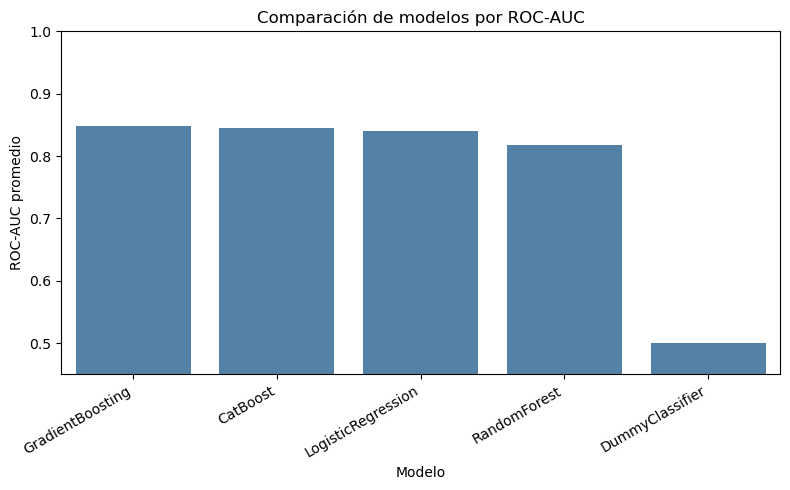

In [333]:
import seaborn as sns
import matplotlib.pyplot as plt

# Preparar datos para el gráfico
comparison_plot = (
    model_comparison
    .set_index("model")["roc_auc_mean"]
)

# Crear el gráfico con seaborn
plt.figure(figsize=(8, 5))

sns.barplot(
    x=comparison_plot.index,
    y=comparison_plot.values,
    color="steelblue"
)

# Títulos y etiquetas
plt.title("Comparación de modelos por ROC-AUC")
plt.xlabel("Modelo")
plt.ylabel("ROC-AUC promedio")
plt.xticks(rotation=30, ha="right")
plt.ylim(0.45, 1.0)

plt.tight_layout()
plt.show()

# 12. Optimización de hiperparámetros

Aquí el objetivo ya no es comparar familias de modelos, sino mejorar de forma controlada a los candidatos que demostraron mejor desempeño en el punto 11:

- **GradientBoostingClassifier**
- **CatBoostClassifier**

Y mantenemos a **LogisticRegression** como baseline de referencia.

La regla principal sigue siendo la misma:

X_test y y_test continúan congelados.

Toda la optimización se hará exclusivamente sobre X_train y y_train mediante validación cruzada estratificada.

# 12.1 ¿Qué es un hiperparámetro?

Un hiperparámetro es una configuración que definimos antes de entrenar un modelo.

Por ejemplo, en Gradient Boosting:

```text
n_estimators
learning_rate
max_depth
subsample
```

Estos valores no se aprenden directamente de los datos como los coeficientes de una Regresión Logística.

Nosotros decidimos qué valores probar y después evaluamos cuáles funcionan mejor mediante validación.

## 12.2 ¿Por qué no probar miles de combinaciones?

Una búsqueda excesivamente grande puede:

- Consumir mucho tiempo.
- Sobreoptimizar respecto a la validación.
- Dificultar la interpretación de las mejoras.
- Hacer el proyecto innecesariamente complejo.

Nuestro conjunto de entrenamiento tiene aproximadamente:

```text
5,634 clientes
```

Por eso utilizaremos una búsqueda acotada y razonada.

## Secuencia de trabajo

```text
Modelo baseline
        ↓
Espacio de búsqueda razonable
        ↓
RandomizedSearchCV
        ↓
Mejor configuración
        ↓
Validación del resultado
```

## 12.3 ¿Por qué `RandomizedSearchCV`?

Podríamos utilizar:

```python
GridSearchCV
```

Pero si definimos:

```text
5 valores × 4 valores × 4 valores × 3 valores
```

terminaríamos evaluando rápidamente cientos de combinaciones.

`RandomizedSearchCV` selecciona un número limitado de combinaciones dentro del espacio disponible.

Esto suele ser más eficiente para una primera optimización.

In [334]:
# importamos

from sklearn.model_selection import RandomizedSearchCV

## 12.4 Optimización de Gradient Boosting

Primero debemos entender qué representa cada hiperparámetro.

### `n_estimators`

Número de árboles construidos.

Más árboles pueden aumentar la capacidad del modelo, pero también:

- Incrementar el tiempo de entrenamiento.
- Aumentar el riesgo de sobreajuste.

Valores razonables:

```python
[100, 200, 300, 400]
```

### `learning_rate`

Controla cuánto contribuye cada árbol al modelo final.

Normalmente se explora el equilibrio entre:

```text
learning_rate bajo + muchos árboles
learning_rate alto + menos árboles
```

### `max_depth`

Controla la profundidad máxima de los árboles individuales.

```text
Árboles poco profundos → menor complejidad y menor riesgo de overfitting
Árboles profundos       → más interacciones y mayor riesgo de overfitting
```

### `min_samples_leaf`

Define el número mínimo de observaciones que debe contener una hoja.

Valores mayores pueden regularizar el árbol y reducir el sobreajuste.

### `subsample`

Indica la fracción de datos utilizada para entrenar cada árbol.

Por ejemplo:

```text
subsample = 0.8
```

significa utilizar aproximadamente el 80% de los datos en cada iteración.

Esto introduce aleatoriedad y puede ayudar a reducir el sobreajuste.

## 12.5 Definir Gradient Boosting para tuning

Ya tenemos el preprocesador.

In [335]:
# Creamos un pipeline específico:

gb_tuning_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            GradientBoostingClassifier(
                random_state=42
            )
        )
    ]
)

In [336]:
# espacio de búsqueda

gb_param_distributions = {
    "model__n_estimators": [ # model__ significa: este hiperparámetro pertenece al paso "model" del Pipeline.
        100,
        200,
        300,
        400
    ],
    "model__learning_rate": [
        0.01,
        0.03,
        0.05,
        0.1
    ],
    "model__max_depth": [
        2,
        3,
        4,
        5
    ],
    "model__min_samples_leaf": [
        1,
        5,
        10,
        20
    ],
    "model__subsample": [
        0.7,
        0.8,
        0.9,
        1.0
    ]
}

## 12.6 Ejecutar RandomizedSearchCV

Usaremos la misma validación cruzada:

In [337]:
gb_random_search = RandomizedSearchCV(
    estimator=gb_tuning_pipeline,
    param_distributions=gb_param_distributions,
    n_iter=30, # prueba 30 combinaciones diferentes.
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [338]:
# sí hacemos .fit() porque estamos en la fase de optimización. seguimos utilizando solo Train.

gb_random_search.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'model__learning_rate': [0.01, 0.03, ...], 'model__max_depth': [2, 3, ...], 'model__min_samples_leaf': [1, 5, ...], 'model__n_estimators': [100, 200, ...], ...}"
,n_iter,30
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


## 12.7 Obtener el mejor Gradient Boosting

In [339]:
print(
    "Mejor ROC-AUC CV:",
    gb_random_search.best_score_
)

Mejor ROC-AUC CV: 0.8504664200773536


In [340]:
gb_random_search.best_params_

{'model__subsample': 0.7,
 'model__n_estimators': 300,
 'model__min_samples_leaf': 20,
 'model__max_depth': 2,
 'model__learning_rate': 0.03}

In [341]:
best_gb_pipeline = (
    gb_random_search.best_estimator_
)

## 12.8 No te quedes únicamente con best_score_

In [342]:
gb_search_results = pd.DataFrame(
    gb_random_search.cv_results_
)

In [343]:
gb_search_results = (
    gb_search_results[
        [
            "rank_test_score",
            "mean_test_score",
            "std_test_score",
            "params"
        ]
    ]
    .sort_values("rank_test_score")
)

gb_search_results.head(10)

,rank_test_score,mean_test_score,std_test_score,params
23,1,0.850466,0.009280,"{'model__subsample': 0.7, 'model__n_estimators..."
16,2,0.850313,0.009327,"{'model__subsample': 0.7, 'model__n_estimators..."
1,3,0.850301,0.010088,"{'model__subsample': 0.8, 'model__n_estimators..."
22,4,0.850121,0.008715,"{'model__subsample': 0.8, 'model__n_estimators..."
8,5,0.849897,0.009499,"{'model__subsample': 0.7, 'model__n_estimators..."
10,6,0.849195,0.009988,"{'model__subsample': 0.9, 'model__n_estimators..."
18,7,0.849108,0.009860,"{'model__subsample': 0.7, 'model__n_estimators..."
26,8,0.848769,0.010418,"{'model__subsample': 0.9, 'model__n_estimators..."
0,9,0.848707,0.009882,"{'model__subsample': 0.8, 'model__n_estimators..."
24,10,0.848431,0.009436,"{'model__subsample': 0.9, 'model__n_estimators..."


## 12.9 Comparar Gradient Boosting baseline vs tuned

baseline GB = 0.8477

In [344]:
gb_tuned_auc = gb_random_search.best_score_

gb_improvement = (
    gb_tuned_auc - gb_roc_auc_mean
)

print(
    f"Gradient Boosting baseline: "
    f"{gb_roc_auc_mean:.4f}"
)

print(
    f"Gradient Boosting tuned: "
    f"{gb_tuned_auc:.4f}"
)

print(
    f"Mejora absoluta: "
    f"{gb_improvement:.4f}"
)

Gradient Boosting baseline: 0.8477
Gradient Boosting tuned: 0.8505
Mejora absoluta: 0.0028


### Optimización de Gradient Boosting

Gradient Boosting obtuvo el mejor AUC-ROC promedio durante la comparación inicial de algoritmos, por lo que se seleccionó como uno de los principales candidatos para optimización.

Se utilizó `RandomizedSearchCV` con validación cruzada estratificada de cinco folds y AUC-ROC como criterio de selección.

La búsqueda exploró diferentes combinaciones de número de estimadores, tasa de aprendizaje, profundidad de los árboles, número mínimo de observaciones por hoja y proporción de muestras utilizadas en cada etapa.

El objetivo de la búsqueda es mejorar el rendimiento del modelo manteniendo una estrategia de evaluación consistente y evitando utilizar el conjunto de prueba durante la selección de hiperparámetros.

## 12.10 Ahora CatBoost

Aquí tenemos una decisión interesante.

En el punto 11 utilizamos: **OneHotEncoder → CatBoost** para mantener la misma estructura experimental.

Para el tuning inicial conservaría ese enfoque.

## 12.11 Hiperparámetros importantes de CatBoost

### `iterations`

Número de árboles construidos.

Es conceptualmente similar a:

```text
n_estimators
```

### `depth`

Controla la profundidad de los árboles.

Valores razonables:

```python
[4, 5, 6, 7, 8]
```

### `learning_rate`

Controla la velocidad con la que el modelo incorpora la contribución de cada árbol.

### `l2_leaf_reg`

Es la regularización L2 aplicada a las hojas de los árboles.

Valores mayores pueden ayudar a controlar el *overfitting*.

## 12.12 Pipeline CatBoost para tuning

In [345]:
cat_tuning_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            CatBoostClassifier(
                loss_function="Logloss",
                eval_metric="AUC",
                verbose=0,
                random_seed=42
            )
        )
    ]
)

In [346]:
# espacio

cat_param_distributions = {
    "model__iterations": [
        200,
        300,
        400,
        500
    ],
    "model__depth": [
        4,
        5,
        6,
        7,
        8
    ],
    "model__learning_rate": [
        0.01,
        0.03,
        0.05,
        0.1
    ],
    "model__l2_leaf_reg": [
        1,
        3,
        5,
        7,
        10
    ]
}

## 12.13 RandomizedSearchCV para CatBoost

In [347]:
cat_random_search = RandomizedSearchCV(
    estimator=cat_tuning_pipeline,
    param_distributions=cat_param_distributions,
    n_iter=30,
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [348]:
cat_random_search.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,estimator,Pipeline(step...x14ff555d0>)])
,param_distributions,"{'model__depth': [4, 5, ...], 'model__iterations': [200, 300, ...], 'model__l2_leaf_reg': [1, 3, ...], 'model__learning_rate': [0.01, 0.03, ...]}"
,n_iter,30
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


## 12.14 Recuperar el mejor CatBoost

In [349]:
print(
    "Mejor ROC-AUC CV:",
    cat_random_search.best_score_
)

Mejor ROC-AUC CV: 0.8506014954114652


In [350]:
cat_tuned_auc = (
    cat_random_search.best_score_
)

cat_random_search.best_params_

{'model__learning_rate': 0.03,
 'model__l2_leaf_reg': 5,
 'model__iterations': 200,
 'model__depth': 4}

In [351]:
best_cat_pipeline = (
    cat_random_search.best_estimator_
)

## 12.15 No te quedes únicamente con best_score_

In [352]:
cat_search_results = pd.DataFrame(
    cat_random_search.cv_results_
)

cat_search_results = (
    cat_search_results[
        [
            "rank_test_score",
            "mean_test_score",
            "std_test_score",
            "params"
        ]
    ]
    .sort_values("rank_test_score")
)

cat_search_results.head(10)

,rank_test_score,mean_test_score,std_test_score,params
10,1,0.850601,0.010255,"{'model__learning_rate': 0.03, 'model__l2_leaf..."
13,2,0.850587,0.010308,"{'model__learning_rate': 0.01, 'model__l2_leaf..."
2,3,0.850395,0.009446,"{'model__learning_rate': 0.03, 'model__l2_leaf..."
14,4,0.850306,0.010011,"{'model__learning_rate': 0.01, 'model__l2_leaf..."
12,5,0.850039,0.010422,"{'model__learning_rate': 0.01, 'model__l2_leaf..."
4,6,0.849483,0.010417,"{'model__learning_rate': 0.03, 'model__l2_leaf..."
29,7,0.849483,0.010927,"{'model__learning_rate': 0.01, 'model__l2_leaf..."
7,8,0.849106,0.009801,"{'model__learning_rate': 0.05, 'model__l2_leaf..."
20,9,0.848928,0.009794,"{'model__learning_rate': 0.03, 'model__l2_leaf..."
1,10,0.848297,0.009904,"{'model__learning_rate': 0.01, 'model__l2_leaf..."


## 12.16 Comparar baseline vs tuned

In [353]:
cat_improvement = (
    cat_tuned_auc - cat_roc_auc_mean
)

print(
    f"CatBoost baseline: "
    f"{cat_roc_auc_mean:.4f}"
)

print(
    f"CatBoost tuned: "
    f"{cat_tuned_auc:.4f}"
)

print(
    f"Mejora absoluta: "
    f"{cat_improvement:.4f}"
)

CatBoost baseline: 0.8448
CatBoost tuned: 0.8506
Mejora absoluta: 0.0059


### Optimización de CatBoost

CatBoost presentó uno de los mejores resultados durante la comparación de modelos y la menor variabilidad de AUC-ROC entre los principales candidatos.

Se realizó una búsqueda aleatoria de hiperparámetros utilizando validación cruzada estratificada de cinco folds y AUC-ROC como métrica principal.

Se exploraron diferentes valores para el número de iteraciones, profundidad de los árboles, tasa de aprendizaje y regularización L2.

En esta etapa se mantuvo el mismo esquema de preprocesamiento empleado en la comparación inicial para evitar modificar simultáneamente el algoritmo, la representación de los datos y los hiperparámetros.

## 12.17 Crear tabla de optimización

In [354]:
tuning_results = pd.DataFrame({
    "model": [
        "GradientBoosting",
        "CatBoost"
    ],
    "baseline_auc": [
        gb_roc_auc_mean,
        cat_roc_auc_mean
    ],
    "tuned_auc": [
        gb_tuned_auc,
        cat_tuned_auc
    ]
})

In [355]:
tuning_results["improvement"] = (
    tuning_results["tuned_auc"]
    - tuning_results["baseline_auc"]
)

In [356]:
tuning_results

,model,baseline_auc,tuned_auc,improvement
0,GradientBoosting,0.847651,0.850466,0.002816
1,CatBoost,0.844751,0.850601,0.005851


### Resultados de la optimización

La optimización produjo mejoras moderadas en ambos modelos.

Gradient Boosting aumentó su AUC-ROC promedio de aproximadamente 0.8477 a 0.8505, mientras que CatBoost aumentó de aproximadamente 0.8448 a 0.8506.

CatBoost presentó la mayor mejora absoluta, cercana a 0.0059 puntos de AUC-ROC.

Sin embargo, después de la optimización el desempeño de ambos modelos es prácticamente equivalente:

```text
Gradient Boosting → ROC-AUC ≈ 0.8505
CatBoost          → ROC-AUC ≈ 0.8506
```

## 12.18 CatBoost con manejo nativo de variables categóricas

Durante los experimentos anteriores, `CatBoostClassifier` recibió las variables categóricas después de aplicar `OneHotEncoder`.

Sin embargo, CatBoost dispone de mecanismos propios para trabajar directamente con variables categóricas. Por este motivo, se realizó un experimento adicional utilizando las columnas categóricas originales del conjunto de entrenamiento.

El objetivo es determinar si el tratamiento nativo de categorías permite capturar mejor las relaciones presentes en los datos que la representación mediante One-Hot Encoding.

Para mantener una comparación metodológicamente consistente:

* se utiliza el mismo conjunto `X_train`;
* se mantiene la misma validación cruzada estratificada de cinco folds;
* AUC-ROC continúa siendo la métrica principal;
* el conjunto de prueba permanece completamente aislado;
* se excluyen las mismas variables asociadas a identificadores y posible fuga de información.

En esta configuración no se utiliza el `ColumnTransformer` ni `OneHotEncoder`. Las variables categóricas se indican directamente al modelo mediante el parámetro `cat_features`.

Primero se evalúa una configuración baseline comparable con la utilizada previamente y posteriormente se realiza una búsqueda de hiperparámetros mediante `RandomizedSearchCV`.

De esta forma es posible separar dos efectos:

1. el efecto de cambiar la representación de las variables categóricas;
2. el efecto de la optimización de hiperparámetros.

Los resultados se compararán contra las versiones anteriores de CatBoost con One-Hot Encoding antes de seleccionar el modelo que pasará a la evaluación final.


## 12.18.1 ¿Por qué hacer este experimento?

Hasta ahora, el flujo utilizado para CatBoost ha sido:

```text
Variables categóricas
        ↓
OneHotEncoder
        ↓
48 columnas transformadas
        ↓
CatBoost
```

Este flujo funciona, pero CatBoost está diseñado para trabajar directamente con variables categóricas.

Por eso probaremos también:

```text
X_train original
23 variables
        ↓
CatBoost
identificando las columnas categóricas
        ↓
Predicción
```

Este enfoque podría tener dos ventajas:

- Evitar la expansión de categorías mediante One-Hot Encoding.
- Permitir que CatBoost aprenda relaciones entre categorías mediante su mecanismo interno.

Sin embargo, no asumiremos que será mejor. Su rendimiento deberá medirse mediante validación.

## 12.18.2 ¿Qué variables vamos a considerar categóricas?

In [357]:
# comprobar las categorias

categorical_features

['Type',
 'PaperlessBilling',
 'PaymentMethod',
 'gender',
 'Partner',
 'Dependents',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'MultipleLines']

In [358]:
X_train[categorical_features].dtypes

Type                object
PaperlessBilling    object
PaymentMethod       object
gender              object
Partner             object
Dependents          object
InternetService     object
OnlineSecurity      object
OnlineBackup        object
DeviceProtection    object
TechSupport         object
StreamingTV         object
StreamingMovies     object
MultipleLines       object
dtype: object

## 12.18.3 ¿Qué hacemos con nuestras variables binarias y conteos?

Además de las variables categóricas, tenemos:

```python
binary_discrete_features = [
    "SeniorCitizen",
    "HasInternet",
    "HasPhone",
    "InternetAddOnCount",
    "StreamingCount",
    "HasTechProtection",
    "AutomaticPayment"
]
```

Las mantendremos como variables numéricas.

Es una decisión razonable porque sus valores tienen una interpretación clara:

```text
HasInternet          → 0 / 1
HasPhone             → 0 / 1
InternetAddOnCount   → 0–4
StreamingCount       → 0–2
```

CatBoost puede utilizar correctamente estos valores numéricos.

No es necesario convertir todas las variables en categóricas.

## 12.18.4 Importante: aquí desaparece el `preprocessor`

El CatBoost anterior utilizaba:

```python
Pipeline([
    ("preprocessor", preprocessor),
    ("model", catboost_model)
])
```

Para CatBoost nativo no utilizaremos ese pipeline.

Trabajaremos directamente con:

```text
X_train
   ↓
CatBoostClassifier
```

La razón es que queremos conservar las columnas categóricas originales para que CatBoost las procese internamente.

Esto no es un error.

Es precisamente el propósito del experimento.

## 12.18.5 Primero: CatBoost nativo baseline

Antes de hacer tuning, realizaremos una comparación metodológicamente importante.

No compararemos directamente:

```text
CatBoost OHE baseline
vs.
CatBoost native tuned
```

Esto implicaría cambiar dos elementos al mismo tiempo:

```text
Representación
+
Hiperparámetros
```

Primero compararemos dos modelos CatBoost con prácticamente la misma configuración baseline.

Nuestro CatBoost original tenía:

```python
CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.05,
    loss_function="Logloss",
    eval_metric="AUC",
    verbose=0,
    random_seed=42
)
```

In [359]:
# creamos la versión nativa

native_catboost_model = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.05,
    loss_function="Logloss",
    eval_metric="AUC",
    cat_features=categorical_features, # estas columnas no deben tratarse simplemente como valores numéricos o texto genérico; son variables categóricas.
    verbose=0,
    random_seed=42,
    allow_writing_files=False,
    thread_count=1
)

## 12.18.6 ¿Por qué `allow_writing_files=False`?

CatBoost suele crear automáticamente una carpeta:

```text
catboost_info/
```

Esta carpeta contiene información relacionada con el entrenamiento.

Para el notebook no la necesitamos.

Por eso utilizamos:

```python
allow_writing_files=False
```

Esta configuración mantiene más limpio el proyecto.

## 12.18.7 ¿Por qué `thread_count=1`?

Más adelante utilizaremos:

```python
n_jobs=-1
```

en `RandomizedSearchCV`.

Esto significa que Scikit-learn intentará ejecutar varios entrenamientos en paralelo.

Si, además, cada modelo CatBoost intentara utilizar todos los núcleos disponibles, podríamos provocar:

```text
Muchos procesos
×
Muchos threads
=
Sobreutilización del CPU
```

Por eso dejamos:

```python
thread_count=1
```

dentro de CatBoost y permitimos que `RandomizedSearchCV` controle la paralelización exterior.

## 12.18.8 Validación cruzada del baseline nativo

Utilizamos exactamente el mismo:

```text
cv
```

y:

```text
scoring
```

del punto 10.

In [360]:
native_cat_cv_results = cross_validate(
    native_catboost_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)

In [361]:
native_cat_roc_auc_mean = (
    native_cat_cv_results["test_roc_auc"].mean()
)

native_cat_roc_auc_std = (
    native_cat_cv_results["test_roc_auc"].std()
)

native_cat_accuracy_mean = (
    native_cat_cv_results["test_accuracy"].mean()
)

native_cat_accuracy_std = (
    native_cat_cv_results["test_accuracy"].std()
)

In [362]:
# mostramos

print(
    f"Native CatBoost ROC-AUC: "
    f"{native_cat_roc_auc_mean:.4f} "
    f"± {native_cat_roc_auc_std:.4f}"
)

print(
    f"Native CatBoost Accuracy: "
    f"{native_cat_accuracy_mean:.4f} "
    f"± {native_cat_accuracy_std:.4f}"
)

Native CatBoost ROC-AUC: 0.8480 ± 0.0097
Native CatBoost Accuracy: 0.8053 ± 0.0088


## 12.18.9 Primera comparación: ¿el manejo nativo ayudó?

Ahora tenemos como referencia del punto 11:

- CatBoost + OHE baseline
- ROC-AUC ≈ 0.8448

In [363]:
# Comparar

native_vs_ohe_baseline = pd.DataFrame({
    "model": [
        "CatBoost + OneHotEncoder",
        "CatBoost Native"
    ],
    "roc_auc_mean": [
        cat_roc_auc_mean,
        native_cat_roc_auc_mean
    ],
    "roc_auc_std": [
        cat_roc_auc_std,
        native_cat_roc_auc_std
    ],
    "accuracy_mean": [
        cat_accuracy_mean,
        native_cat_accuracy_mean
    ],
    "accuracy_std": [
        cat_accuracy_std,
        native_cat_accuracy_std
    ]
})

native_vs_ohe_baseline

,model,roc_auc_mean,roc_auc_std,accuracy_mean,accuracy_std
0,CatBoost + OneHotEncoder,0.844751,0.007541,0.800673,0.008447
1,CatBoost Native,0.847987,0.009691,0.805288,0.008772


## 12.18.10 Ahora sí: tuning del CatBoost nativo

Independientemente de si mejora mucho o poco, tiene sentido optimizar la versión nativa para hacer una comparación final justa contra nuestro CatBoost OHE optimizado.

In [364]:
# Creamos

native_cat_tuning_model = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="AUC",
    cat_features=categorical_features,
    verbose=0,
    random_seed=42,
    allow_writing_files=False,
    thread_count=1
)

## 12.18.11 Espacio de hiperparámetros

Vamos a mantener un espacio comparable al utilizado anteriormente:

In [365]:
native_cat_param_distributions = {
    "iterations": [
        200,
        300,
        400,
        500
    ],
    "depth": [
        4,
        5,
        6,
        7,
        8
    ],
    "learning_rate": [
        0.01,
        0.03,
        0.05,
        0.1
    ],
    "l2_leaf_reg": [
        1,
        3,
        5,
        7,
        10
    ]
}

## 12.18.12 RandomizedSearchCV

In [366]:
# Creamos

native_cat_random_search = RandomizedSearchCV(
    estimator=native_cat_tuning_model,
    param_distributions=native_cat_param_distributions,
    n_iter=30,
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [367]:
native_cat_random_search.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,estimator,<catboost.cor...t 0x14dcba9b0>
,param_distributions,"{'depth': [4, 5, ...], 'iterations': [200, 300, ...], 'l2_leaf_reg': [1, 3, ...], 'learning_rate': [0.01, 0.03, ...]}"
,n_iter,30
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


## 12.18.13 Obtener mejor resultado

In [368]:
native_cat_tuned_auc = (
    native_cat_random_search.best_score_
)

print(
    f"Mejor ROC-AUC CV CatBoost Native: "
    f"{native_cat_tuned_auc:.6f}"
)

Mejor ROC-AUC CV CatBoost Native: 0.850246


In [369]:
native_cat_random_search.best_params_

{'learning_rate': 0.03, 'l2_leaf_reg': 10, 'iterations': 500, 'depth': 4}

In [370]:
best_native_cat_model = (
    native_cat_random_search.best_estimator_
)

## 12.18.14 Analizar Top 10

In [371]:
native_cat_search_results = pd.DataFrame(
    native_cat_random_search.cv_results_
)

In [372]:
native_cat_search_results = (
    native_cat_search_results[
        [
            "rank_test_score",
            "mean_test_score",
            "std_test_score",
            "params"
        ]
    ]
    .sort_values("rank_test_score")
)

native_cat_search_results.head(10)

,rank_test_score,mean_test_score,std_test_score,params
20,1,0.850246,0.010080,"{'learning_rate': 0.03, 'l2_leaf_reg': 10, 'it..."
2,2,0.850149,0.010461,"{'learning_rate': 0.03, 'l2_leaf_reg': 7, 'ite..."
21,3,0.849985,0.010649,"{'learning_rate': 0.1, 'l2_leaf_reg': 7, 'iter..."
7,4,0.849934,0.010374,"{'learning_rate': 0.05, 'l2_leaf_reg': 7, 'ite..."
26,5,0.849707,0.010355,"{'learning_rate': 0.05, 'l2_leaf_reg': 7, 'ite..."
10,6,0.849663,0.010172,"{'learning_rate': 0.03, 'l2_leaf_reg': 5, 'ite..."
0,7,0.849559,0.010465,"{'learning_rate': 0.03, 'l2_leaf_reg': 5, 'ite..."
4,8,0.849316,0.010795,"{'learning_rate': 0.03, 'l2_leaf_reg': 7, 'ite..."
15,9,0.848717,0.010475,"{'learning_rate': 0.05, 'l2_leaf_reg': 1, 'ite..."
6,10,0.848716,0.010616,"{'learning_rate': 0.03, 'l2_leaf_reg': 5, 'ite..."


## 12.18.15 Comparación final del experimento

Ahora tendremos cuatro versiones relevantes:
```
CatBoost OHE baseline
CatBoost Native baseline
CatBoost OHE tuned
CatBoost Native tuned
```

In [373]:
# Construimos

catboost_experiment = pd.DataFrame({
    "model": [
        "CatBoost OHE Baseline",
        "CatBoost Native Baseline",
        "CatBoost OHE Tuned",
        "CatBoost Native Tuned"
    ],
    "roc_auc": [
        cat_roc_auc_mean,
        native_cat_roc_auc_mean,
        cat_tuned_auc,
        native_cat_tuned_auc
    ]
})

In [374]:
catboost_experiment = (
    catboost_experiment
    .sort_values(
        "roc_auc",
        ascending=False
    )
    .reset_index(drop=True)
)

catboost_experiment

,model,roc_auc
0,CatBoost OHE Tuned,0.850601
1,CatBoost Native Tuned,0.850246
2,CatBoost Native Baseline,0.847987
3,CatBoost OHE Baseline,0.844751


### Conclusión del experimento con categorías nativas

El uso nativo de variables categóricas mejoró el desempeño del CatBoost baseline, pasando de un AUC-ROC aproximado de 0.8448 con One-Hot Encoding a 0.8480 con categorías nativas.

Sin embargo, después de la optimización de hiperparámetros, ambas estrategias presentaron resultados prácticamente equivalentes:

```text
CatBoost OHE Tuned    → ROC-AUC ≈ 0.8506
CatBoost Native Tuned → ROC-AUC ≈ 0.8502
```

# 13. Evaluación final sobre el conjunto de prueba

Después de completar la comparación de algoritmos, la optimización de hiperparámetros y el experimento adicional con el manejo nativo de variables categóricas, se seleccionó `CatBoostClassifier` con One-Hot Encoding como modelo final.

La selección se realizó antes de evaluar el conjunto de prueba, utilizando como criterio principal el AUC-ROC promedio obtenido mediante validación cruzada.

El CatBoost optimizado obtuvo el mayor AUC-ROC promedio entre las configuraciones evaluadas, aunque su rendimiento fue prácticamente equivalente al de Gradient Boosting optimizado.

El conjunto de prueba se mantuvo completamente aislado durante:

* la selección de variables;
* la comparación de algoritmos;
* la selección de hiperparámetros;
* la optimización de los modelos.

Por primera vez en esta etapa se utiliza `X_test` para estimar la capacidad de generalización del modelo seleccionado sobre observaciones que no participaron durante el proceso de desarrollo.

La evaluación principal se realizará mediante **AUC-ROC**, mientras que **Accuracy** se utilizará como métrica adicional.

También se analizarán precision, recall, F1-score y la matriz de confusión para comprender el comportamiento del modelo sobre la clase de churn.

No se utilizarán los resultados del conjunto de prueba para volver a ajustar hiperparámetros o modificar el modelo, con el objetivo de preservar la independencia de esta evaluación final.


## 13.1 ¿Qué representa ahora `X_test`?

Desde el punto 8 dejamos apartado aproximadamente el 20 % de los clientes:

```text
Train → 5634 observaciones
Test  → 1409 observaciones
```

Este conjunto no participó en:

- Preprocesamiento aprendido.
- Selección de modelos.
- Cross-validation.
- Tuning de hiperparámetros.
- Selección del modelo final.

Ahora funciona como una simulación de datos nuevos que el modelo nunca vio durante el desarrollo.

Esto hace que esta evaluación sea mucho más importante que cualquier score individual obtenido durante CV.

## 13.2 No necesitamos volver a entrenar el modelo

Tenemos:

```python
best_cat_pipeline = cat_random_search.best_estimator_
```

`RandomizedSearchCV`, con su comportamiento estándar `refit=True`, ya realizó dos tareas:

- Encontró la mejor configuración mediante validación cruzada.
- Volvió a entrenar el mejor estimador utilizando todo `X_train`.

Por tanto:

```python
best_cat_pipeline
```

ya está entrenado.

No es necesario ejecutar nuevamente:

```python
best_cat_pipeline.fit(X_train, y_train)
```

Hacerlo tampoco sería conceptualmente grave, pero sería redundante.

## 13.3 Primero obtenemos probabilidades

Para AUC-ROC necesitamos probabilidades, no solamente predicciones 0/1.

In [375]:
y_test_proba = best_cat_pipeline.predict_proba(X_test)[:, 1] # [:, 1] predict_proba() devuelve dos probabilidades por cliente:

## ¿Qué significa `[:, 1]`?

`predict_proba()` devuelve dos probabilidades por cliente:

```text
P(Churn = 0)    P(Churn = 1)
```

Nos interesa la segunda:

```text
P(Churn = 1)
```

porque nuestra clase positiva es:

```text
Cliente que canceló
```

Por ejemplo, conceptualmente:

```text
Cliente A → 0.08
Cliente B → 0.42
Cliente C → 0.91
```

El cliente C sería considerado mucho más riesgoso.

## 13.4 Obtener predicciones binarias

Para Accuracy necesitamos las clases predichas:

In [376]:
y_test_pred = best_cat_pipeline.predict(X_test)

Por defecto, la clasificación corresponde esencialmente a una decisión alrededor de:

```
probabilidad ≥ 0.5 → Churn
probabilidad < 0.5 → No Churn
```
Más adelante veremos por qué ese 0.5 no necesariamente tiene que ser el threshold óptimo para Marketing.

## 13.5 Calcular AUC-ROC final

In [377]:
final_roc_auc = roc_auc_score(
    y_test,
    y_test_proba
)

print(
    f"Test ROC-AUC: "
    f"{final_roc_auc:.4f}"
)

Test ROC-AUC: 0.8440


## 13.6 Calcular Accuracy final

In [378]:
final_accuracy = accuracy_score(
    y_test,
    y_test_pred
)

print(
    f"Test Accuracy: "
    f"{final_accuracy:.4f}"
)

Test Accuracy: 0.8077


## 13.7 Mostrar ambas juntas

In [379]:
print("Evaluación final — CatBoost Tuned")
print("-" * 40)

print(
    f"ROC-AUC:  {final_roc_auc:.4f}"
)

print(
    f"Accuracy: {final_accuracy:.4f}"
)

Evaluación final — CatBoost Tuned
----------------------------------------
ROC-AUC:  0.8440
Accuracy: 0.8077


## 13.8 Comparar CV vs Test

In [380]:
final_evaluation = pd.DataFrame({
    "metric": [
        "ROC-AUC"
    ],
    "cross_validation": [
        cat_tuned_auc
    ],
    "test": [
        final_roc_auc
    ]
})

In [381]:
final_evaluation["difference"] = (
    final_evaluation["test"]
    - final_evaluation["cross_validation"]
)

final_evaluation

,metric,cross_validation,test,difference
0,ROC-AUC,0.850601,0.843972,-0.00663


## 13.9 Interpretación de la diferencia entre validación cruzada y Test

El modelo obtuvo un AUC-ROC promedio de aproximadamente 0.8506 durante la validación cruzada y 0.8440 sobre el conjunto de prueba.

La diferencia es de aproximadamente -0.0066, lo que representa una reducción pequeña del rendimiento sobre datos no observados.

La proximidad entre ambas métricas sugiere que el modelo mantiene una capacidad de generalización consistente y que no existe evidencia de una caída severa de desempeño respecto a la validación cruzada.

## 13.10 Ahora sí podemos generar classification_report

In [382]:
print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=[
            "No Churn",
            "Churn"
        ]
    )
)

              precision    recall  f1-score   support

    No Churn       0.84      0.91      0.87      1035
       Churn       0.67      0.53      0.60       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409



## 13.11 Matriz de confusión

In [383]:
from sklearn.metrics import ConfusionMatrixDisplay

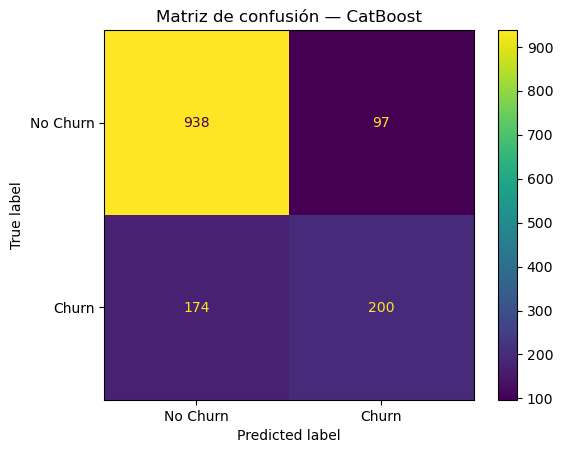

In [384]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    display_labels=[
        "No Churn",
        "Churn"
    ]
)

plt.title(
    "Matriz de confusión — CatBoost"
)

plt.show()

## 13.12 Interpretación de la matriz de confusión

La matriz de confusión muestra que el modelo identificó correctamente 200 de los 374 clientes que realmente cancelaron el servicio.

Sin embargo, 174 clientes que finalmente cancelaron fueron clasificados como `No Churn`, lo que representa falsos negativos.

Desde la perspectiva del negocio, estos falsos negativos son especialmente relevantes porque corresponden a clientes que podrían quedar fuera de una campaña preventiva de retención.

Por otro lado, 97 clientes fueron clasificados como posibles casos de churn aunque realmente permanecieron en el servicio. Estos falsos positivos podrían representar promociones o acciones de retención dirigidas a clientes que no las necesitaban.

El equilibrio entre falsos negativos y falsos positivos dependerá del costo comercial de cada tipo de error.

## 13.13 Curva ROC

In [385]:
from sklearn.metrics import RocCurveDisplay

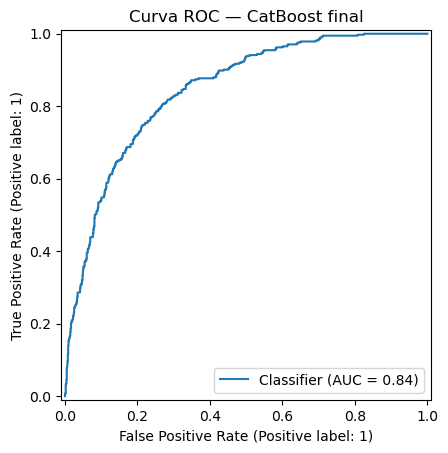

In [386]:
RocCurveDisplay.from_predictions(
    y_test,
    y_test_proba
)

plt.title(
    "Curva ROC — CatBoost final"
)

plt.show()

## 13.12 Guardar una tabla compacta del modelo final

In [387]:
final_model_results = pd.DataFrame({
    "model": [
        "CatBoost OHE Tuned"
    ],
    "cv_roc_auc": [
        cat_tuned_auc
    ],
    "test_roc_auc": [
        final_roc_auc
    ],
    "test_accuracy": [
        final_accuracy
    ]
})

final_model_results

,model,cv_roc_auc,test_roc_auc,test_accuracy
0,CatBoost OHE Tuned,0.850601,0.843972,0.807665


# 14. Interpretabilidad del modelo

Después de evaluar el desempeño del modelo final sobre el conjunto de prueba, se analiza qué variables tienen mayor influencia en sus predicciones.

El objetivo de esta etapa no es modificar ni volver a optimizar el modelo, sino comprender cómo utiliza las características de los clientes para estimar el riesgo de cancelación.

Se utilizan dos aproximaciones complementarias:

1. **Importancia interna de características de CatBoost**, que permite identificar qué variables fueron utilizadas con mayor intensidad por el modelo.
2. **Valores SHAP**, que permiten estimar la magnitud de la contribución de cada característica sobre las predicciones.

Debido a que el pipeline utiliza `OneHotEncoder`, algunas variables categóricas se encuentran representadas mediante múltiples columnas. Por ello, además de analizar las características transformadas, sus importancias se agregan nuevamente a nivel de variable original para facilitar la interpretación desde una perspectiva de negocio.

Las importancias obtenidas representan asociaciones predictivas dentro del modelo y no deben interpretarse como relaciones causales.


## 14.1 ¿Por qué necesitamos interpretabilidad?

Un modelo predictivo puede tener buen AUC, pero desde el punto de vista empresarial necesitamos comprender qué información está utilizando.

Por ejemplo, Marketing no quiere únicamente recibir:

```text
Cliente 12345 → probabilidad de churn = 0.81
```

También interesa saber qué características aparecen como relevantes en las predicciones:

- Tipo de contrato.
- Método de pago.
- Cargos mensuales.
- Servicios adicionales.
- Tipo de internet.

Esto permite conectar el modelo con acciones de negocio.

Sin embargo, existe una regla muy importante:

```text
Importancia predictiva ≠ causalidad
```

Si `PaymentMethod` aparece como importante, no podemos concluir automáticamente que cambiar el método de pago evitará el churn.

Solo podemos afirmar que el modelo encontró esa variable útil para distinguir clientes con distintos patrones de cancelación.

## 14.2 Recuperar el preprocesador y el CatBoost final

In [388]:
# Nuestro modelo final está dentro de:

best_cat_pipeline

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('continuous', ...), ('binary_discrete', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [389]:
# extraer sus dos componentes:

final_preprocessor = (
    best_cat_pipeline.named_steps["preprocessor"]
)

final_model = (
    best_cat_pipeline.named_steps["model"]
)

In [390]:
# comprobar

final_preprocessor

,transformers,"[('continuous', ...), ('binary_discrete', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


In [391]:
final_model

## 14.3 Recuperar los nombres de las variables transformadas

Empezamos con:

```
23 features
```
y después del OneHotEncoder terminamos aproximadamente con:

```
48 features
```
Recuperamos sus nombres:

In [392]:
final_feature_names = (
    final_preprocessor.get_feature_names_out()
)

len(final_feature_names)

48

In [393]:
final_feature_names[:20]

array(['continuous__MonthlyCharges', 'continuous__TotalCharges',
       'binary_discrete__SeniorCitizen', 'binary_discrete__HasInternet',
       'binary_discrete__HasPhone', 'binary_discrete__InternetAddOnCount',
       'binary_discrete__StreamingCount',
       'binary_discrete__HasTechProtection',
       'binary_discrete__AutomaticPayment',
       'categorical__Type_Month-to-month', 'categorical__Type_One year',
       'categorical__Type_Two year', 'categorical__PaperlessBilling_No',
       'categorical__PaperlessBilling_Yes',
       'categorical__PaymentMethod_Bank transfer (automatic)',
       'categorical__PaymentMethod_Credit card (automatic)',
       'categorical__PaymentMethod_Electronic check',
       'categorical__PaymentMethod_Mailed check',
       'categorical__gender_Female', 'categorical__gender_Male'],
      dtype=object)

## 14.4 Recuperar las importancias de CatBoost

In [394]:
feature_importances = (
    final_model.get_feature_importance()
)

In [395]:
# comprobar

len(feature_importances)

48

In [396]:
len(final_feature_names)

48

In [397]:
assert (
    len(feature_importances)
    == len(final_feature_names)
)

## 14.5 Crear tabla de importancia

In [398]:
feature_importance_df = pd.DataFrame({
    "feature": final_feature_names,
    "importance": feature_importances
})

In [399]:
# Ordenamos

feature_importance_df = (
    feature_importance_df
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)

feature_importance_df.head(20)

,feature,importance
0,continuous__TotalCharges,21.515240
1,categorical__Type_Month-to-month,18.586463
2,categorical__InternetService_Fiber optic,12.255822
3,categorical__Type_Two year,9.031432
4,continuous__MonthlyCharges,6.859157
5,categorical__OnlineSecurity_No,4.116528
6,categorical__TechSupport_No,3.349272
7,categorical__PaymentMethod_Electronic check,3.301470
8,binary_discrete__StreamingCount,3.173818
9,binary_discrete__InternetAddOnCount,3.048778


## 14.6 ¿Qué significa esta importancia?

Es importante interpretar correctamente la importancia de las variables en el notebook.

Una feature con mayor importancia significa aproximadamente que:

```text
El modelo utilizó esa variable en mayor medida para construir sus predicciones.
```

Sin embargo, no significa necesariamente que:

```text
Esa variable aumenta el churn.
```

Tampoco significa que:

```text
Eliminar esa condición reducirá el churn.
```

La importancia nos indica:

```text
Qué variables utiliza mucho el modelo
```

pero todavía no necesariamente:

```text
En qué dirección actúan.
```

Por ejemplo, si aparece:

```text
Type_Month-to-month
```

como una variable muy importante, la importancia por sí sola no indica si esa característica aumenta o disminuye la probabilidad de churn.

Para analizar la dirección y la contribución de una variable en predicciones concretas necesitaríamos herramientas adicionales, como SHAP. Los valores SHAP pueden mostrar si una característica empuja una predicción hacia una mayor o menor probabilidad de churn, aunque esa interpretación sigue describiendo el comportamiento del modelo y no demuestra causalidad. [20][21]

Por ejemplo:

```text
Importancia de la variable
→ Qué tanto utiliza el modelo esa variable.

Valor SHAP
→ Cómo contribuye esa variable a una predicción específica.
```

Así, una variable puede ser muy importante globalmente, pero su efecto puede variar entre clientes: para algunos puede aumentar la probabilidad predicha de churn y para otros reducirla. La importancia global suele calcularse con valores SHAP absolutos, por lo que resume la magnitud de la contribución sin conservar su dirección. [18][22]

## 14.7 Graficar las 15 variables transformadas más importantes

In [400]:
top_features = (
    feature_importance_df
    .head(15)
    .sort_values("importance")
)

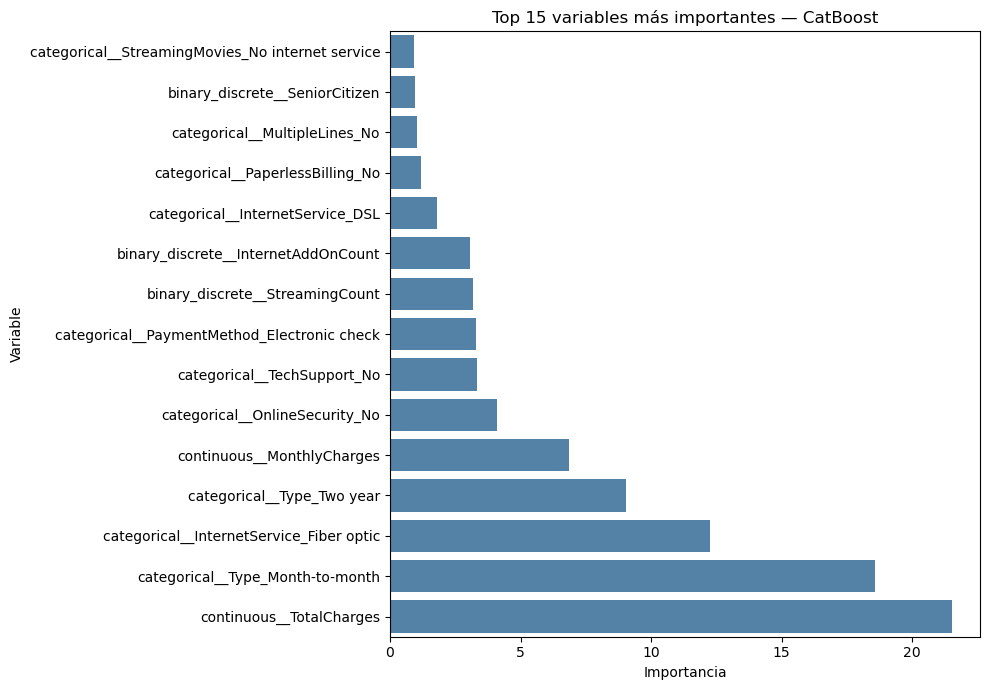

In [401]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="importance",
    y="feature",
    orient="h",
    color="steelblue"
)

plt.title("Top 15 variables más importantes — CatBoost")
plt.xlabel("Importancia")
plt.ylabel("Variable")

plt.tight_layout()
plt.show()

## 14.8 Recuperar la variable original

Vamos a construir una función que convierta:

```text
categorical__Type_Month-to-month
```

en:

```text
Type
```

y:

```text
continuous__MonthlyCharges
```

en:

```text
MonthlyCharges
```

In [402]:
def get_original_feature(
    transformed_feature,
    categorical_features
):
    """
    Recupera el nombre de la variable original
    a partir del nombre generado por
    ColumnTransformer / OneHotEncoder.
    """

    clean_name = (
        transformed_feature
        .split("__", 1)[-1]
    )

    if transformed_feature.startswith(
        "categorical__"
    ):
        for feature in sorted(
            categorical_features,
            key=len,
            reverse=True
        ):
            if (
                clean_name == feature
                or clean_name.startswith(
                    f"{feature}_"
                )
            ):
                return feature

    return clean_name

In [403]:
feature_importance_df[
    "original_feature"
] = feature_importance_df[
    "feature"
].apply(
    lambda x: get_original_feature(
        x,
        categorical_features
    )
)

In [404]:
# Comprobar

feature_importance_df[
    [
        "feature",
        "original_feature",
        "importance"
    ]
].head(20)

,feature,original_feature,importance
0,continuous__TotalCharges,TotalCharges,21.515240
1,categorical__Type_Month-to-month,Type,18.586463
2,categorical__InternetService_Fiber optic,InternetService,12.255822
3,categorical__Type_Two year,Type,9.031432
4,continuous__MonthlyCharges,MonthlyCharges,6.859157
5,categorical__OnlineSecurity_No,OnlineSecurity,4.116528
6,categorical__TechSupport_No,TechSupport,3.349272
7,categorical__PaymentMethod_Electronic check,PaymentMethod,3.301470
8,binary_discrete__StreamingCount,StreamingCount,3.173818
9,binary_discrete__InternetAddOnCount,InternetAddOnCount,3.048778


## 14.9 Agrupar importancia por variable original

Sumar las importancias de todas las categorías pertenecientes a la misma variable

In [405]:
grouped_feature_importance = (
    feature_importance_df
    .groupby(
        "original_feature",
        as_index=False
    )["importance"]
    .sum()
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)

grouped_feature_importance

,original_feature,importance
0,Type,28.123549
1,TotalCharges,21.515240
2,InternetService,14.048990
3,MonthlyCharges,6.859157
4,OnlineSecurity,4.489049
5,TechSupport,4.278738
6,PaymentMethod,4.238514
7,StreamingCount,3.173818
8,InternetAddOnCount,3.048778
9,PaperlessBilling,2.005418


In [406]:
# Comprobar

grouped_feature_importance.shape

(23, 2)

## 14.10 Graficar las variables originales

In [407]:
# Seleccionamos las 15 principales:

top_original_features = (
    grouped_feature_importance
    .head(15)
    .sort_values("importance")
)

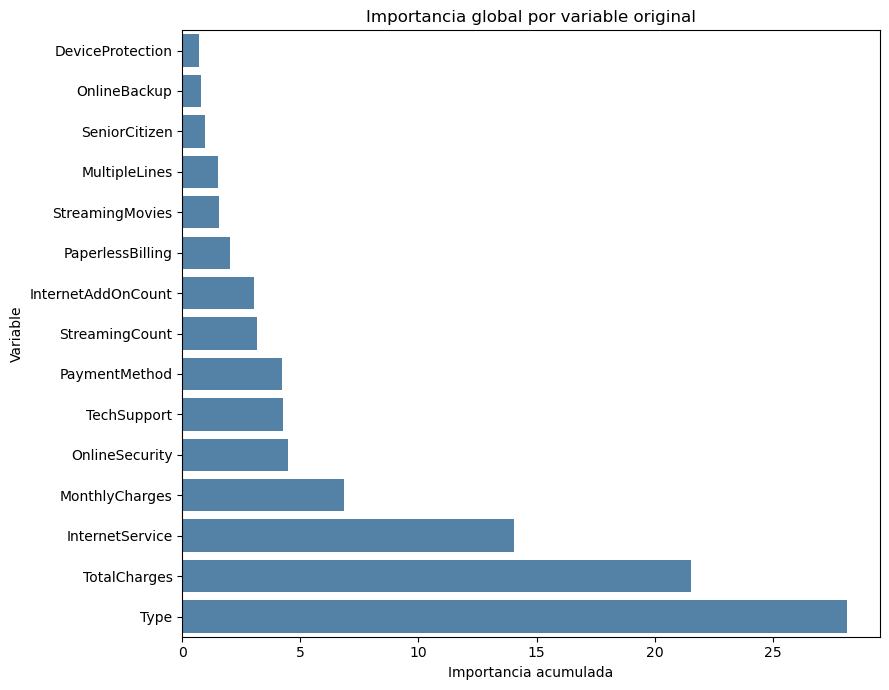

In [408]:
# Ordenar de mayor a menor importancia
top_original_features_sorted = top_original_features.sort_values(
    "importance",
    ascending=True  # Para horizontal: ascending=True muestra el mayor arriba
)

plt.figure(figsize=(9, 7))

sns.barplot(
    data=top_original_features_sorted,
    x="importance",
    y="original_feature",
    color="steelblue"
)

plt.title("Importancia global por variable original")
plt.xlabel("Importancia acumulada")
plt.ylabel("Variable")

plt.tight_layout()
plt.show()

## 14.11 Comprobar que las importancias conservan el total

In [409]:
# validación

print(
    "Importancia transformada:",
    feature_importance_df[
        "importance"
    ].sum()
)

print(
    "Importancia agrupada:",
    grouped_feature_importance[
        "importance"
    ].sum()
)

Importancia transformada: 100.0
Importancia agrupada: 100.0


## 14.12 Importancia agregada por variable original

El preprocesamiento mediante `OneHotEncoder` convierte algunas variables categóricas en múltiples columnas binarias.

Por ejemplo, la variable `Type` puede convertirse en columnas independientes para contratos mensuales, de un año y de dos años.

Por este motivo, interpretar únicamente las columnas transformadas podría fragmentar la importancia de una misma característica.

Para facilitar la interpretación desde una perspectiva de negocio, las importancias correspondientes a categorías derivadas de una misma variable se agregaron nuevamente bajo el nombre de la característica original.

Esta transformación no modifica el modelo ni sus predicciones; únicamente reorganiza las importancias obtenidas para facilitar su interpretación.

## 14.13 ¿Usamos SHAP?

Sí, pero de forma controlada.

CatBoost dispone de cálculo de valores SHAP propio, por lo que no necesitamos necesariamente instalar la librería externa shap.

Esto es especialmente útil en nuestro caso.

Necesitamos primero transformar los datos con el mismo preprocesador:

In [410]:
X_test_transformed = (
    final_preprocessor.transform(X_test)
)

## 14.14 Crear un Pool de CatBoost

In [411]:
from catboost import Pool

In [412]:
test_pool = Pool(
    X_test_transformed,
    label=y_test
)

In [413]:
# solicitar valores SHAP

shap_values = (
    final_model.get_feature_importance(
        test_pool,
        type="ShapValues"
    )
)

In [414]:
shap_values.shape

(1409, 49)

La última columna representa el: expected value

In [415]:
# separamos

shap_feature_values = (
    shap_values[:, :-1]
)

shap_expected_value = (
    shap_values[:, -1]
)

In [416]:
# comprobar

shap_feature_values.shape

(1409, 48)

## 14.15 Importancia SHAP global

In [417]:
# calcular

mean_abs_shap = (
    np.abs(
        shap_feature_values
    ).mean(axis=0)
)

## ¿Por qué valor absoluto?

Una variable puede:

```text
Aumentar el riesgo
```

para algunos clientes y:

```text
Disminuirlo
```

para otros.

Si promediáramos directamente:

```text
+0.5
-0.5
```

podríamos obtener:

```text
0
```

y concluir incorrectamente que no tiene efecto.

Con:

```text
mean(|SHAP|)
```

medimos la magnitud media de su contribución.

## 14.16 Crear tabla SHAP

In [418]:
shap_importance_df = pd.DataFrame({
    "feature": final_feature_names,
    "mean_abs_shap": mean_abs_shap
})

In [419]:
# ordenamos

shap_importance_df = (
    shap_importance_df
    .sort_values(
        "mean_abs_shap",
        ascending=False
    )
    .reset_index(drop=True)
)

shap_importance_df.head(20)

,feature,mean_abs_shap
0,continuous__TotalCharges,0.525195
1,categorical__Type_Month-to-month,0.402574
2,categorical__InternetService_Fiber optic,0.387665
3,categorical__Type_Two year,0.236264
4,continuous__MonthlyCharges,0.209205
5,categorical__PaymentMethod_Electronic check,0.183597
6,categorical__OnlineSecurity_No,0.169798
7,categorical__TechSupport_No,0.165817
8,binary_discrete__StreamingCount,0.111391
9,categorical__PaperlessBilling_No,0.056605


## 14.17 Agrupar SHAP por variable original

In [420]:
shap_importance_df[
    "original_feature"
] = shap_importance_df[
    "feature"
].apply(
    lambda x: get_original_feature(
        x,
        categorical_features
    )
)

In [421]:
grouped_shap_importance = (
    shap_importance_df
    .groupby(
        "original_feature",
        as_index=False
    )["mean_abs_shap"]
    .sum()
    .sort_values(
        "mean_abs_shap",
        ascending=False
    )
    .reset_index(drop=True)
)

grouped_shap_importance

,original_feature,mean_abs_shap
0,Type,0.644379
1,TotalCharges,0.525195
2,InternetService,0.408885
3,PaymentMethod,0.214213
4,MonthlyCharges,0.209205
5,TechSupport,0.189911
6,OnlineSecurity,0.183127
7,StreamingCount,0.111391
8,PaperlessBilling,0.107254
9,MultipleLines,0.072274


## 14.18 Gráfica SHAP global

In [422]:
top_shap_features = (
    grouped_shap_importance
    .head(15)
    .sort_values("mean_abs_shap")
)

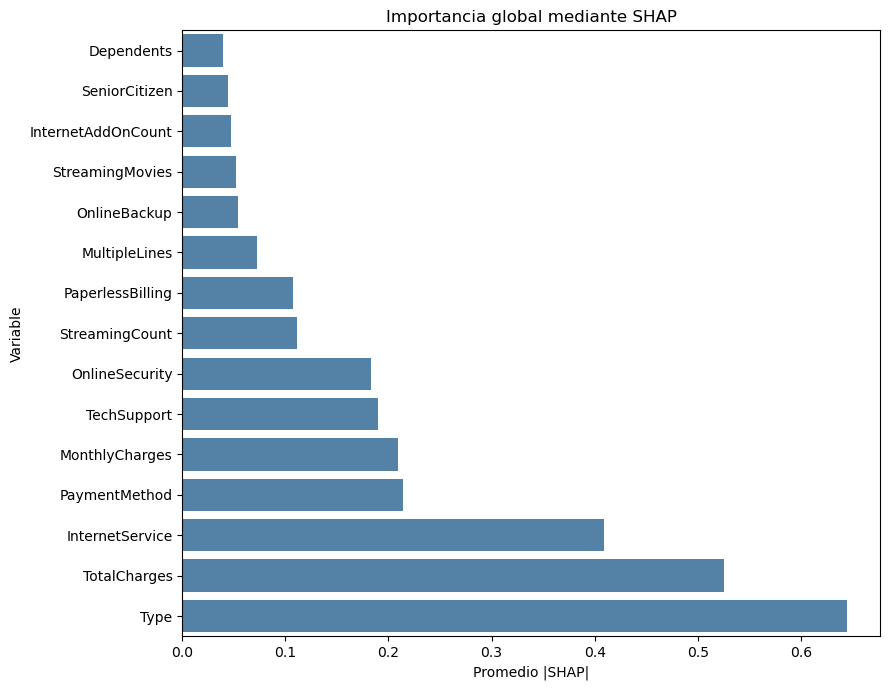

In [423]:
# Ordenar de mayor a menor importancia
top_shap_features_sorted = top_shap_features.sort_values(
    "mean_abs_shap",
    ascending=True  # Para horizontal: ascending=True muestra el mayor arriba
)

plt.figure(figsize=(9, 7))

sns.barplot(
    data=top_shap_features_sorted,
    x="mean_abs_shap",
    y="original_feature",
    color="steelblue"
)

plt.title("Importancia global mediante SHAP")
plt.xlabel("Promedio |SHAP|")
plt.ylabel("Variable")

plt.tight_layout()
plt.show()

## 14.19 Conclusiones de interpretabilidad

Los análisis de importancia interna de CatBoost y de valores SHAP muestran resultados consistentes.

Las variables con mayor relevancia predictiva fueron:

- `Type`
- `TotalCharges`
- `InternetService`
- `PaymentMethod`
- `MonthlyCharges`
- `TechSupport`
- `OnlineSecurity`

El tipo de contrato aparece como la característica dominante en ambos métodos de interpretación, seguido por los cargos acumulados y el tipo de servicio de Internet.

Estos resultados son consistentes con patrones identificados previamente durante el análisis exploratorio. Por ejemplo, los contratos mes a mes, determinados métodos de pago, algunos tipos de servicio de Internet y la ausencia de ciertos servicios adicionales mostraron tasas de churn diferentes entre grupos.

Las variables creadas durante el feature engineering también aportaron información al modelo, aunque algunas presentaron una importancia reducida debido a que su información ya estaba contenida parcialmente en variables originales. Por ejemplo, `AutomaticPayment` está estrechamente relacionado con `PaymentMethod`, mientras que `HasInternet` resume información ya representada por `InternetService`.

La coincidencia general entre la importancia interna de CatBoost y la importancia global mediante SHAP aumenta la confianza en que el modelo utiliza de forma consistente un conjunto identificable de características para estimar el riesgo de cancelación.

Estas importancias representan asociaciones predictivas y no relaciones causales. Por lo tanto, los resultados pueden utilizarse para identificar segmentos de clientes que requieren mayor análisis o acciones de retención, pero no permiten afirmar que modificar una característica concreta provocará directamente una reducción del churn.

# 15. Conclusiones de negocio y recomendaciones

## 15.1 Objetivo de negocio

El objetivo del proyecto fue desarrollar un modelo capaz de identificar clientes con mayor riesgo de cancelar los servicios de Interconnect.

La finalidad de esta predicción es proporcionar al área de Marketing una herramienta que permita priorizar clientes para acciones preventivas de retención, como ofertas personalizadas, promociones o modificaciones de plan.

El problema se abordó como una tarea de clasificación binaria:

- `Churn = 1`: cliente que canceló el servicio.
- `Churn = 0`: cliente que permanece activo.

La métrica principal utilizada para evaluar los modelos fue AUC-ROC, complementada con Accuracy y métricas específicas de clasificación como precision, recall y F1-score.

## 15.2 Desempeño del modelo final

Después de comparar diferentes algoritmos y realizar optimización de hiperparámetros, se seleccionó un modelo `CatBoostClassifier` utilizando variables categóricas transformadas mediante One-Hot Encoding.

El rendimiento final sobre el conjunto de prueba fue aproximadamente:

| Métrica | Resultado |
|---|---:|
| AUC-ROC | 0.8440 |
| Accuracy | 0.8077 |
| Precision — Churn | 0.67 |
| Recall — Churn | 0.53 |
| F1-score — Churn | 0.60 |

El AUC-ROC de aproximadamente 0.844 indica que el modelo presenta una capacidad discriminativa útil para ordenar clientes según su riesgo estimado de cancelación..

La diferencia entre el AUC obtenido mediante validación cruzada y el observado sobre el conjunto de prueba fue pequeña, lo que sugiere un comportamiento razonablemente consistente sobre datos no utilizados durante el desarrollo.

## 15.3 Interpretación desde la perspectiva de negocio

El modelo no debe entenderse únicamente como un clasificador que asigna las etiquetas `Churn` o `No Churn`.

Su principal utilidad para Marketing es la probabilidad estimada de cancelación de cada cliente.

Esta probabilidad puede utilizarse como un score de riesgo que permita ordenar a los clientes desde menor hasta mayor probabilidad de churn.

Por ejemplo, en lugar de aplicar una campaña de retención a toda la cartera de clientes, Interconnect podría priorizar a los clientes ubicados en los niveles superiores de riesgo.

De esta forma, el modelo puede funcionar como una herramienta de priorización para asignar de manera más eficiente los recursos destinados a retención.

## 15.4 Falsos negativos y oportunidad de mejora

Utilizando el umbral de clasificación predeterminado, el modelo identificó correctamente 200 de los 374 clientes que realmente cancelaron el servicio dentro del conjunto de prueba.

Sin embargo, 174 clientes que cancelaron fueron clasificados como `No Churn`.

Estos falsos negativos representan una limitación importante desde la perspectiva de negocio, debido a que corresponden a clientes en riesgo que podrían quedar fuera de una campaña preventiva de retención.

El recall de aproximadamente 0.53 muestra que el modelo detecta alrededor de la mitad de las cancelaciones reales utilizando el umbral de clasificación estándar.

Por este motivo, una implementación comercial no debería asumir automáticamente que un threshold de 0.5 representa la mejor decisión de negocio.

En una etapa de implementación sería recomendable analizar distintos umbrales considerando el costo de una oferta de retención, el valor económico de conservar un cliente y el costo asociado a no detectar una cancelación.

## 15.5 Principales características asociadas con el riesgo de churn

Los análisis de importancia de características y valores SHAP identificaron un conjunto consistente de variables con alta relevancia predictiva.

Entre las características más importantes se encuentran:

- `Type`
- `TotalCharges`
- `InternetService`
- `PaymentMethod`
- `MonthlyCharges`
- `TechSupport`
- `OnlineSecurity`

El tipo de contrato fue la variable con mayor importancia predictiva, seguido de los cargos acumulados y el tipo de servicio de Internet.

Estos resultados también son consistentes con patrones observados durante el análisis exploratorio, donde determinados tipos de contrato, métodos de pago, servicios de Internet y ausencia de algunos servicios adicionales presentaron diferentes tasas observadas de churn.

Las relaciones identificadas representan asociaciones predictivas y no deben interpretarse como relaciones causales.


## 15.6 Segmentos prioritarios para análisis de retención

Los resultados sugieren que Marketing debería prestar especial atención a combinaciones de características asociadas con mayores niveles observados o predichos de churn.

Entre los segmentos que podrían priorizarse para análisis se encuentran clientes con contratos de menor duración, determinados métodos de pago, clientes con determinados niveles elevados de cargos mensuales y ausencia de servicios como soporte técnico o seguridad en línea.

También resulta relevante analizar los clientes de determinados tipos de servicio de Internet, debido a que `InternetService` presentó una elevada importancia tanto en el modelo como en los análisis de interpretabilidad.

Estas características no deben utilizarse de forma aislada para decidir acciones comerciales. La recomendación es utilizar la probabilidad estimada por el modelo como indicador principal de riesgo y utilizar las características del cliente para comprender y segmentar ese riesgo.

## 15.7 Recomendaciones para el área de Marketing

A partir de los resultados obtenidos, se recomienda utilizar el modelo como sistema de priorización de clientes para campañas de retención.

Una posible estrategia consiste en generar periódicamente un score de probabilidad de churn para cada cliente activo y ordenar la cartera de acuerdo con dicho riesgo.

Los clientes con mayor probabilidad podrían ser analizados mediante estrategias de retención diferenciadas, por ejemplo:

- ofertas para migrar de contratos mensuales hacia contratos de mayor duración;
- revisión de planes para clientes con cargos mensuales elevados;
- promociones o pruebas de servicios de soporte técnico y seguridad en línea;
- incentivos relacionados con métodos de pago automáticos cuando resulte comercialmente adecuado;
- campañas específicas para segmentos que presenten elevados scores de churn.

Estas acciones deberían tratarse inicialmente como hipótesis comerciales derivadas de asociaciones predictivas.

Para determinar si una intervención realmente reduce el churn, Interconnect debería validar las estrategias mediante experimentos controlados, por ejemplo pruebas A/B, comparando grupos de clientes con y sin intervención.

## 15.8 Selección del umbral de decisión

El umbral predeterminado de 0.5 utilizado durante la evaluación permite disponer de una referencia estándar del comportamiento del modelo.

Sin embargo, dicho umbral no necesariamente representa la mejor decisión desde una perspectiva comercial.

Reducir el threshold podría aumentar el número de clientes churn detectados, pero también incrementaría los falsos positivos y, por lo tanto, el número de promociones dirigidas a clientes que probablemente no cancelarían.

La selección del threshold debería realizarse a partir de información económica como:

- costo promedio de una acción de retención;
- valor esperado de conservar un cliente;
- costo de adquisición de un nuevo cliente;
- pérdida esperada asociada al churn;
- presupuesto disponible para campañas.

Con esta información sería posible optimizar el punto de operación del modelo según el beneficio esperado para la empresa y no únicamente según una métrica estadística.

## 15.9 Limitaciones

El proyecto presenta varias limitaciones que deben considerarse antes de utilizar el modelo en un entorno productivo.

En primer lugar, el modelo final obtuvo un AUC-ROC aproximado de 0.844 sobre el conjunto de prueba, por lo que existe margen para mejorar su capacidad predictiva.

El recall de churn utilizando el umbral predeterminado fue aproximadamente 0.53, lo que implica que una proporción significativa de cancelaciones reales no fue detectada.

Además, el conjunto de datos contiene principalmente información contractual, demográfica y de servicios. No se dispone de variables potencialmente relevantes como:

- satisfacción del cliente;
- número de reclamaciones;
- interrupciones o fallas del servicio;
- calidad de conexión;
- llamadas al centro de atención;
- historial de promociones;
- modificaciones recientes del plan;
- comportamiento de uso;
- interacciones recientes con soporte.

La variable `HistoricalTenure` calculada durante el análisis no fue utilizada en el modelo principal debido a que para clientes que cancelaron depende de la fecha real de cancelación, lo que introduciría fuga de información temporal.

Finalmente, las relaciones encontradas por el modelo representan asociaciones predictivas y no permiten establecer causalidad entre las características de los clientes y la cancelación.

## 15.10 Recomendaciones para futuras versiones

Para mejorar el sistema predictivo sería recomendable incorporar nuevas fuentes de información relacionadas con la experiencia y el comportamiento reciente del cliente.

También sería útil desarrollar un esquema de datos temporal que permita generar snapshots históricos de clientes en diferentes fechas.

Esto permitiría calcular correctamente variables como antigüedad del cliente en el momento de predicción y entrenar modelos que simulen de manera más realista una situación productiva.

Otras líneas de trabajo podrían incluir:

- construcción de nuevas variables de comportamiento;
- evaluación de modelos adicionales de gradient boosting;
- análisis de calibración de probabilidades;
- selección de threshold basada en costos de negocio;
- monitoreo de drift de datos y rendimiento;
- reentrenamiento periódico del modelo;
- experimentos controlados para validar estrategias de retención.

La incorporación de estas mejoras debería evaluarse utilizando nuevos conjuntos de validación temporal o datos futuros, evitando reutilizar el conjunto de prueba empleado en este proyecto.

## 15.11 Propuesta de uso operacional

En una implementación productiva, el modelo podría integrarse dentro de un proceso periódico de scoring de clientes.

El flujo podría seguir la siguiente lógica:

Clientes activos

→ preparación de variables
→ modelo de churn
→ probabilidad de cancelación
→ ranking de riesgo
→ segmentación
→ campaña de retención
→ medición de resultados

Cada cliente recibiría una probabilidad estimada de churn.

Posteriormente, el área de Marketing podría definir segmentos de riesgo, por ejemplo:

- Riesgo bajo
- Riesgo medio
- Riesgo alto

Los límites de estos segmentos no deberían establecerse arbitrariamente, sino definirse en función de la distribución de probabilidades, capacidad operativa del área y costos de intervención.

Los resultados de las campañas deberían almacenarse para evaluar posteriormente si las acciones de retención generan una reducción real del churn.

## 15.12 Conclusión general

El proyecto permitió desarrollar un sistema predictivo capaz de estimar el riesgo de cancelación de clientes de Interconnect.

Después de integrar y preparar las diferentes fuentes de información, se analizaron los principales patrones asociados con churn, se desarrollaron nuevas características, se compararon diferentes algoritmos y se optimizaron los modelos con mejor desempeño.

El modelo final basado en CatBoost obtuvo un AUC-ROC aproximado de 0.844 y una Accuracy cercana a 0.808 sobre datos no utilizados durante su desarrollo.

Los análisis de interpretabilidad mostraron que características relacionadas con el tipo de contrato, cargos acumulados, servicio de Internet, método de pago, cargos mensuales y determinados servicios adicionales tienen una elevada relevancia predictiva.

Desde una perspectiva de negocio, la principal utilidad del modelo consiste en proporcionar un score de riesgo que permita priorizar clientes para análisis y campañas de retención.

Sin embargo, las decisiones comerciales no deberían basarse únicamente en una clasificación binaria ni asumir relaciones causales a partir de las asociaciones encontradas.

Una implementación real debería combinar las probabilidades generadas por el modelo con información económica, capacidad operativa y experimentación controlada para determinar qué estrategias de retención producen mayor valor para la empresa.

## 16 Exportación del pipeline para producción

El modelo oficial se exporta como un único artefacto que contiene tanto el preprocesamiento como el `CatBoostClassifier` seleccionado.

Se serializa `best_cat_pipeline` en lugar de `final_model`, ya que el primero encapsula el `ColumnTransformer`, el escalado, el One-Hot Encoding y el modelo final. Esto permite aplicar exactamente las mismas transformaciones durante inferencia que durante entrenamiento.

In [424]:
from pathlib import Path
import joblib

model_path = Path("../models/churn_pipeline.joblib")

joblib.dump(
    best_cat_pipeline,
    model_path
)

print(f"Pipeline guardado en: {model_path}")

Pipeline guardado en: ../models/churn_pipeline.joblib


### Verificación del artefacto serializado

Después de exportar el pipeline, se vuelve a cargar desde disco y se comparan sus predicciones con las producidas por el objeto original en memoria.

Esta comprobación permite verificar que la serialización conserva correctamente tanto el preprocesamiento como el modelo entrenado antes de utilizar el artefacto en una API o aplicación externa.

In [425]:
loaded_pipeline = joblib.load(
    "../models/churn_pipeline.joblib"
)

# Probabilidades del pipeline original
original_proba = best_cat_pipeline.predict_proba(
    X_test
)[:, 1]

# Probabilidades del pipeline cargado desde disco
loaded_proba = loaded_pipeline.predict_proba(
    X_test
)[:, 1]

# Predicciones de clase
original_pred = best_cat_pipeline.predict(
    X_test
)

loaded_pred = loaded_pipeline.predict(
    X_test
)

# Comparaciones
probabilities_match = np.allclose(
    original_proba,
    loaded_proba
)

predictions_match = np.array_equal(
    original_pred,
    loaded_pred
)

max_probability_difference = np.max(
    np.abs(original_proba - loaded_proba)
)

print(
    "Probabilidades idénticas:",
    probabilities_match
)

print(
    "Predicciones idénticas:",
    predictions_match
)

print(
    "Máxima diferencia entre probabilidades:",
    max_probability_difference
)

Probabilidades idénticas: True
Predicciones idénticas: True
Máxima diferencia entre probabilidades: 0.0


## Simular una petición individual

In [426]:
# Seleccionamos un único cliente del conjunto de prueba
sample_customer = X_test.iloc[[0]].copy()

print("Shape:", sample_customer.shape)
sample_customer

Shape: (1, 23)


,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,gender,SeniorCitizen,Partner,Dependents,InternetService,...,TechSupport,StreamingTV,StreamingMovies,MultipleLines,HasInternet,HasPhone,InternetAddOnCount,StreamingCount,HasTechProtection,AutomaticPayment
6095,Month-to-month,Yes,Mailed check,19.65,67.55,Male,0,No,No,No internet service,...,No internet service,No internet service,No internet service,No,0,1,0,0,0,0


In [427]:
sample_probability = loaded_pipeline.predict_proba(
    sample_customer
)[:, 1][0]

sample_prediction = loaded_pipeline.predict(
    sample_customer
)[0]

print(
    "Predicción:",
    int(sample_prediction)
)

print(
    "Probabilidad de churn:",
    float(sample_probability)
)

Predicción: 0
Probabilidad de churn: 0.26085351452633293


In [428]:
# Esto nos dará la lista exacta que más adelante convertiremos en el esquema de FastAPI.
print(
    sample_customer.columns.tolist()
)

['Type', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines', 'HasInternet', 'HasPhone', 'InternetAddOnCount', 'StreamingCount', 'HasTechProtection', 'AutomaticPayment']


In [429]:
# Esto es importante porque Pydantic necesitará saber qué esperamos como:

print(
    sample_customer.dtypes
)

Type                   object
PaperlessBilling       object
PaymentMethod          object
MonthlyCharges        float64
TotalCharges          float64
gender                 object
SeniorCitizen           int64
Partner                object
Dependents             object
InternetService        object
OnlineSecurity         object
OnlineBackup           object
DeviceProtection       object
TechSupport            object
StreamingTV            object
StreamingMovies        object
MultipleLines          object
HasInternet             int64
HasPhone                int64
InternetAddOnCount      int64
StreamingCount          int64
HasTechProtection       int64
AutomaticPayment        int64
dtype: object


In [430]:
sample_customer

,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,gender,SeniorCitizen,Partner,Dependents,InternetService,...,TechSupport,StreamingTV,StreamingMovies,MultipleLines,HasInternet,HasPhone,InternetAddOnCount,StreamingCount,HasTechProtection,AutomaticPayment
6095,Month-to-month,Yes,Mailed check,19.65,67.55,Male,0,No,No,No internet service,...,No internet service,No internet service,No internet service,No,0,1,0,0,0,0


In [431]:
import json

sample_payload = sample_customer.iloc[0].to_dict()

print(
    json.dumps(
        sample_payload,
        indent=2,
        ensure_ascii=False
    )
)

{
  "Type": "Month-to-month",
  "PaperlessBilling": "Yes",
  "PaymentMethod": "Mailed check",
  "MonthlyCharges": 19.65,
  "TotalCharges": 67.55,
  "gender": "Male",
  "SeniorCitizen": 0,
  "Partner": "No",
  "Dependents": "No",
  "InternetService": "No internet service",
  "OnlineSecurity": "No internet service",
  "OnlineBackup": "No internet service",
  "DeviceProtection": "No internet service",
  "TechSupport": "No internet service",
  "StreamingTV": "No internet service",
  "StreamingMovies": "No internet service",
  "MultipleLines": "No",
  "HasInternet": 0,
  "HasPhone": 1,
  "InternetAddOnCount": 0,
  "StreamingCount": 0,
  "HasTechProtection": 0,
  "AutomaticPayment": 0
}


## 17. Perfil de referencia para monitoreo de drift

Se genera un perfil agregado del conjunto de entrenamiento utilizado por el
modelo oficial. El objetivo es disponer de una distribución de referencia
para detectar cambios en los datos recibidos en producción.

El perfil almacena estadísticas y proporciones agregadas, no registros
individuales de clientes.

In [435]:
from pathlib import Path
import sys


# Añadir la raíz del proyecto al path de Python
PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


from monitoring.drift import (
    build_reference_profile,
    save_reference_profile,
)


monitoring_numeric_features = [
    "MonthlyCharges",
    "TotalCharges",
]

monitoring_categorical_features = [
    "Type",
    "PaymentMethod",
    "InternetService",
    "PaperlessBilling",
    "MultipleLines",
]


reference_profile = build_reference_profile(
    reference_df=X_train,
    numeric_features=monitoring_numeric_features,
    categorical_features=monitoring_categorical_features,
)

reference_profile_path = (
    "../monitoring/reference_profile.json"
)

save_reference_profile(
    reference_profile,
    reference_profile_path,
)

print(
    "Reference monitoring profile saved to:",
    reference_profile_path,
)

Reference monitoring profile saved to: ../monitoring/reference_profile.json


### 17.1 Validación del sistema de monitoreo

Como demostración de la infraestructura de drift, se utiliza el conjunto de
prueba como un lote independiente de referencia operacional.

Este conjunto no representa tráfico real de producción. Su uso permite
verificar que el mecanismo de monitoreo puede comparar datos no utilizados
para ajustar el modelo contra el perfil agregado del conjunto de
entrenamiento.

In [439]:
import importlib
import monitoring.drift

importlib.reload(
    monitoring.drift
)

print(
    monitoring.drift.__file__
)

/Volumes/PortableSSD/TripleTen/CDD/Sprint_19/proyecto_interconnect/monitoring/drift.py


In [440]:
hasattr(
    monitoring.drift,
    "generate_drift_report_from_profile",
)

True

In [441]:
from monitoring.drift import (
    generate_drift_report_from_profile,
    load_reference_profile,
)


loaded_reference_profile = load_reference_profile(
    "../monitoring/reference_profile.json"
)


drift_report = generate_drift_report_from_profile(
    profile=loaded_reference_profile,
    current_df=X_test,
)


drift_report

,feature,feature_type,psi,drift_status,reference_mean,current_mean,mean_change_pct
0,TotalCharges,numeric,0.016154,stable,2282.145146,2270.094358,-0.528047
1,MonthlyCharges,numeric,0.009980,stable,64.574494,65.510220,1.449064
2,Type,categorical,0.005251,stable,NaN,NaN,NaN
3,PaymentMethod,categorical,0.003691,stable,NaN,NaN,NaN
4,InternetService,categorical,0.001412,stable,NaN,NaN,NaN
5,MultipleLines,categorical,0.001216,stable,NaN,NaN,NaN
6,PaperlessBilling,categorical,0.000187,stable,NaN,NaN,NaN


In [442]:
drift_report_path = (
    "../monitoring/drift_report_validation.csv"
)

drift_report.to_csv(
    drift_report_path,
    index=False,
)

print(
    "Validation drift report saved to:",
    drift_report_path,
)

Validation drift report saved to: ../monitoring/drift_report_validation.csv


### 17.2 Simulación de un escenario con drift significativo

Para validar que el sistema de monitoreo puede detectar cambios reales en las
distribuciones, se construye un lote sintético a partir del conjunto de prueba.

Este escenario es únicamente una prueba controlada de la infraestructura de
monitorización y no representa datos reales de producción.

In [443]:
synthetic_drift_batch = X_test.copy()


# --------------------------------------------------
# Simular cambio en cargos mensuales
# --------------------------------------------------

synthetic_drift_batch["MonthlyCharges"] = (
    synthetic_drift_batch["MonthlyCharges"]
    + 40
)


# --------------------------------------------------
# Simular cambio en el tipo de contrato
# --------------------------------------------------

synthetic_drift_batch["Type"] = (
    "Month-to-month"
)


# --------------------------------------------------
# Generar reporte de drift
# --------------------------------------------------

synthetic_drift_report = (
    generate_drift_report_from_profile(
        profile=loaded_reference_profile,
        current_df=synthetic_drift_batch,
    )
)


synthetic_drift_report

,feature,feature_type,psi,drift_status,reference_mean,current_mean,mean_change_pct
0,Type,categorical,5.779197,significant,NaN,NaN,NaN
1,MonthlyCharges,numeric,5.727768,significant,64.574494,105.510220,63.393026
2,TotalCharges,numeric,0.016154,stable,2282.145146,2270.094358,-0.528047
3,PaymentMethod,categorical,0.003691,stable,NaN,NaN,NaN
4,InternetService,categorical,0.001412,stable,NaN,NaN,NaN
5,MultipleLines,categorical,0.001216,stable,NaN,NaN,NaN
6,PaperlessBilling,categorical,0.000187,stable,NaN,NaN,NaN


In [444]:
# Guardar el escenario sintético

synthetic_report_path = (
    "../monitoring/drift_report_synthetic.csv"
)

synthetic_drift_report.to_csv(
    synthetic_report_path,
    index=False,
)

print(
    "Synthetic drift report saved to:",
    synthetic_report_path,
)

Synthetic drift report saved to: ../monitoring/drift_report_synthetic.csv


## Crear un lote temporal

In [445]:
monitoring_batch_features = [
    "MonthlyCharges",
    "TotalCharges",
    "Type",
    "PaymentMethod",
    "InternetService",
    "PaperlessBilling",
    "MultipleLines",
]

current_monitoring_batch = (
    X_test[
        monitoring_batch_features
    ].copy()
)

current_batch_path = (
    "../monitoring/current_batch.csv"
)

current_monitoring_batch.to_csv(
    current_batch_path,
    index=False,
)

print(
    "Current monitoring batch saved to:",
    current_batch_path,
)

print(
    "Shape:",
    current_monitoring_batch.shape,
)

Current monitoring batch saved to: ../monitoring/current_batch.csv
Shape: (1409, 7)
